## 📊 Structural Housing Stock Analysis – Netherlands Dataset
### 💡 Introduction

This notebook presents an exploratory dwelling-level structural analysis of the Dutch housing stock. The objective is to:

- Identify relationships between physical dwelling characteristics

- Map internal dependencies within the housing stock

- Prepare a robust feature architecture for later PC6-level aggregation and regression modeling

The analysis begins at micro (dwelling) level, isolating structural building features before incorporating energy consumption or spatial aggregation.

The workflow is designed to:

- First understand housing stock structure

- Then move to compositional PC6 modeling

- And later connect to energy demand modeling

### 1️⃣ Environment Setup

We use:

- pandas for data handling

- numpy for numerical operations

- matplotlib and seaborn for visualization

In [66]:
import scipy
import statsmodels
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.cluster.hierarchy import linkage, fcluster

sns.set(style="whitegrid")

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", plt.matplotlib.__version__)
print("seaborn:", sns.__version__)
print("scipy:", scipy.__version__)
print("statsmodels:", statsmodels.__version__)

pandas: 3.0.1
numpy: 2.4.2
matplotlib: 3.10.8
seaborn: 0.13.2
scipy: 1.17.0
statsmodels: 0.14.6


## 2️⃣ Read and Filter the National Dwelling Dataset (Residential-only PC6s)

In this step we load the national dwelling dataset and directly construct a residential-only dataset. PC6s with 1 or more non-residential building are removed during this step.


The filtering is applied at two levels:

- Row level: keep rows where gebruiksdoelen == "woonfunctie" and sbicode is NaN.

- PC6 level: keep only those postcode areas where all rows satisfy the row-level condition.

We read only the required columns to keep memory use manageable.

In [67]:
file_path = Path(
    r"C:\Users\kosta\Desktop\Thesis\policy-tool-slice\Dutch_load_analysis\dook_vng_data\dook_vng_gemeenten_csv\energiedata-match-gemeentecode_NL.csv"
)
sep = ";"

# read only what we need to identify residential-only PC6 codes
pc6_df = pd.read_csv(
    file_path,
    sep=sep,
    usecols=["postcode", "gebruiksdoelen", "sbicode"],
    dtype=str,
    low_memory=False,
)

pc6_df["is_residential_row"] = (
    pc6_df["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & pc6_df["sbicode"].isna()
)

# keep only PC6 where all rows are residential
residential_pc6_mask = pc6_df.groupby("postcode")["is_residential_row"].all()
residential_pc6_codes = residential_pc6_mask[residential_pc6_mask].index

print("Residential-only PC6 codes:", len(residential_pc6_codes))

# now load the dwelling-level structural variables, restricted to those PC6 codes
usecols_structural = [
    "gemeentecode",
    "postcode",
    "sbicode",
    "gebruiksdoelen",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023",
]

df_structural = pd.read_csv(
    file_path,
    sep=sep,
    usecols=usecols_structural,
    dtype=str,
    low_memory=False,
)

df_structural = df_structural[df_structural["postcode"].isin(residential_pc6_codes)].copy()

# enforce the row-level definition (should be redundant but keeps things explicit)
df_structural = df_structural[
    df_structural["gebruiksdoelen"].astype(str).str.strip().str.lower().eq("woonfunctie")
    & df_structural["sbicode"].isna()
].copy()

# drop constant filter columns
df_structural = df_structural.drop(columns=["gebruiksdoelen", "sbicode"])

final_columns = [
    "gemeentecode",
    "postcode",
    "woning_type",
    "oppervlakte",
    "pand_bouwjaar",
    "energieklasse",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023",
]

df_structural = df_structural[final_columns].copy()

print("Residential-only structural dataset")
print("Rows:", len(df_structural))
print("Unique PC6:", df_structural["postcode"].nunique())

df_structural.head()

Residential-only PC6 codes: 261729
Residential-only structural dataset
Rows: 4881410
Unique PC6: 261729


,gemeentecode,postcode,woning_type,oppervlakte,pand_bouwjaar,energieklasse,gas_ean_count,p6_kwh_2023,p6_kwh_productie_2023,p6_gasm3_2023
0,GM0014,9725CZ,Flatwoning (overig),166.000000,2008,A,0,2471.470000,0.000000,0.000000
1,GM0014,9731HJ,NaN,135.000000,1981,NaN,1,1967.350000,0.000000,938.000000
2,GM0014,9744BD,NaN,163.000000,1912,NaN,1,2682.450000,0.000000,1448.500000
3,GM0014,9736CS,Flatwoning (overig),47.000000,1982,B,1,1647.540000,0.000000,783.520000
5,GM0014,9743RC,Twee-onder-een-kap / rijwoning hoek,114.000000,1970,A,1,2124.250000,0.000000,1221.350000


## 3️⃣ Preparation of the dwelling-level structural dataset

Before analysing the structural characteristics of the housing stock, the dwelling-level dataset must be prepared to ensure that key variables are consistently formatted, numerically interpretable, and free of obvious data issues.

This preparation step focuses on **structural dwelling features**, which will later be used both for exploratory analysis and for aggregation to postcode (PC6) level. The preparation consists of four steps:

1. **Standardizing categorical variables**  
   Text-based categorical variables such as dwelling type (`woning_type`) and energy label (`energieklasse`) are cleaned to ensure consistent formatting and to avoid artificial category duplication caused by whitespace or string inconsistencies.

2. **Converting numeric variables**  
   Structural characteristics (e.g., floor area and construction year) and energy-related variables are explicitly converted to numeric format to ensure that downstream calculations and statistical operations behave correctly.

3. **Removing implausible observations**  
   Basic plausibility checks are applied to remove clearly invalid values, such as missing or non-positive floor areas and construction years that exceed the current year.

4. **Handling energy label availability**  
   Dwellings without a registered energy label are retained in the dataset and assigned to a dedicated category (`no_label`). This allows later analysis to distinguish between labelled dwellings and dwellings for which no official energy label is available.

### 3.1 Structural dataset preparation

In [68]:
# ----------------------------
# 3.1 Structural dataset preparation
# ----------------------------

df_dwelling = df_structural.copy()

# 1) standardize categorical strings
for c in ["woning_type", "energieklasse"]:
    df_dwelling[c] = df_dwelling[c].astype(str).str.strip()

df_dwelling["woning_type"] = df_dwelling["woning_type"].replace({"nan": np.nan, "": np.nan})
df_dwelling["energieklasse"] = df_dwelling["energieklasse"].replace({"nan": np.nan, "": np.nan})

# 2) numeric conversions
num_cols = [
    "oppervlakte",
    "pand_bouwjaar",
    "gas_ean_count",
    "p6_kwh_2023",
    "p6_kwh_productie_2023",
    "p6_gasm3_2023"
]

for c in num_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# 3) remove implausible values
df_dwelling = df_dwelling[df_dwelling["oppervlakte"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["oppervlakte"] > 0].copy()

df_dwelling = df_dwelling[df_dwelling["pand_bouwjaar"].notna()].copy()
df_dwelling = df_dwelling[df_dwelling["pand_bouwjaar"] <= 2026].copy()

# 4) treat dwellings without energy label as structural category
df_dwelling["energieklasse"] = df_dwelling["energieklasse"].fillna("no_label")

label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energieklasse"] = pd.Categorical(
    df_dwelling["energieklasse"],
    categories=label_order,
    ordered=False
)

print("Structural dwelling dataset prepared")
print("Number of dwelling observations:", len(df_dwelling))
print("Number of PC6 areas:", df_dwelling["postcode"].nunique())

Structural dwelling dataset prepared
Number of dwelling observations: 4881409
Number of PC6 areas: 261729


### 3.2 Data integrity diagnostics

Before proceeding with the structural analysis, several diagnostics are performed to verify the integrity and internal consistency of the energy variables included in the dataset.

The dataset contains three energy-related variables:

- `p6_kwh_2023` — electricity consumption  
- `p6_gasm3_2023` — gas consumption  
- `p6_kwh_productie_2023` — electricity production (PV)

Electricity consumption and PV production originate from postcode-level statistics that report **average values per dwelling at PC6 level**. As a result, these values are repeated for all dwellings within the same postcode area in the dataset.  

Gas consumption behaves differently: dwellings without a gas connection have zero gas consumption, meaning that `p6_gasm3_2023` can vary within the same PC6 area depending on the presence of a gas connection.

To verify the integrity of these variables, three diagnostics are performed.

**1. Row-level missing and zero values**

First, the number of missing values and zero values is counted across dwelling observations.  
This provides a basic integrity check and allows identification of potential reporting gaps or structurally meaningful zeros.

**2. PC6-level all-zero checks**

Next, the number of postcode areas where all dwelling rows report zero values is computed.  
This diagnostic identifies postcode areas that appear to have zero electricity consumption, zero gas consumption, or zero PV production across all dwellings.

This information is useful because row-level zeros may arise either from true postcode-level zeros or from dwelling-specific characteristics (such as dwellings without gas connections).

**3. Within-PC6 constancy check**

Finally, we verify that electricity consumption and PV production are constant within each postcode area.  
Since these variables represent postcode-level averages repeated across dwellings, each PC6 area should contain only one unique value for these variables.

Gas consumption is excluded from this constancy check because its variation within PC6 areas reflects meaningful structural differences in gas connectivity between dwellings.

Together, these diagnostics ensure that the energy variables behave consistently with the structure of the source dataset before further analysis is conducted.

In [69]:
# ----------------------------
# 3.2 Data integrity diagnostics
# ----------------------------

# energy variables
energy_cols = [
    "p6_kwh_2023",
    "p6_gasm3_2023",
    "p6_kwh_productie_2023"
]

# ----------------------------
# A. Row-level missing / zero values
# ----------------------------

row_level_check = pd.DataFrame({
    "n_nan_rows": df_dwelling[energy_cols].isna().sum(),
    "n_zero_rows": (df_dwelling[energy_cols] == 0).sum()
})

print("Row-level integrity check for energy variables:")
display(row_level_check)

# ----------------------------
# B. PC6-level all-zero diagnostics
# ----------------------------

pc6_all_zero_check = pd.DataFrame({
    "n_pc6_all_zero": [
        df_dwelling.groupby("postcode")["p6_kwh_2023"].apply(lambda x: (x == 0).all()).sum(),
        df_dwelling.groupby("postcode")["p6_gasm3_2023"].apply(lambda x: (x == 0).all()).sum(),
        df_dwelling.groupby("postcode")["p6_kwh_productie_2023"].apply(lambda x: (x == 0).all()).sum()
    ]
}, index=energy_cols)

print("\nPC6 areas where all dwelling rows have zero energy value:")
display(pc6_all_zero_check)

# ----------------------------
# C. Within-PC6 constancy check
# ----------------------------

constancy_cols = ["p6_kwh_2023", "p6_kwh_productie_2023"]

variation_check = (
    df_dwelling
    .groupby("postcode")[constancy_cols]
    .nunique()
)

n_pc6_with_variation = (variation_check > 1).sum()

print("\nPC6 areas with more than one unique value within postcode:")
display(n_pc6_with_variation)

Row-level integrity check for energy variables:


,n_nan_rows,n_zero_rows
p6_kwh_2023,0,59035
p6_gasm3_2023,0,729690
p6_kwh_productie_2023,0,3421829



PC6 areas where all dwelling rows have zero energy value:


,n_pc6_all_zero
p6_kwh_2023,2974
p6_gasm3_2023,22816
p6_kwh_productie_2023,181101



PC6 areas with more than one unique value within postcode:


p6_kwh_2023              76
p6_kwh_productie_2023    15
dtype: int64

#### Final modelling decision

Postcode areas exhibiting inconsistent electricity or PV values within the same PC6 are removed from the dataset, since these variables represent postcode-level statistics that should be constant across dwellings. In addition, postcode areas reporting zero electricity consumption across all dwellings are excluded from further analysis, as these cases likely reflect measurement artefacts and do not provide meaningful information for modelling residential energy demand.

In [70]:
# ----------------------------
# Remove problematic PC6 areas
# ----------------------------

# 1. PC6 with electricity = 0 across all dwellings
pc6_zero_electricity = (
    df_dwelling
    .groupby("postcode")["p6_kwh_2023"]
    .apply(lambda x: (x == 0).all())
)

pc6_zero_electricity = pc6_zero_electricity[pc6_zero_electricity].index


# 2. PC6 with inconsistent electricity or PV values
pc6_variation = (
    df_dwelling
    .groupby("postcode")[["p6_kwh_2023", "p6_kwh_productie_2023"]]
    .nunique()
)

pc6_inconsistent = pc6_variation[
    (pc6_variation["p6_kwh_2023"] > 1) |
    (pc6_variation["p6_kwh_productie_2023"] > 1)
].index


# 3. Combine both sets
pc6_to_remove = set(pc6_zero_electricity).union(set(pc6_inconsistent))

print("PC6 with zero electricity:", len(pc6_zero_electricity))
print("PC6 with inconsistent electricity/PV:", len(pc6_inconsistent))
print("Total PC6 removed:", len(pc6_to_remove))


# 4. Remove them
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_to_remove)
].copy()

print("\nDataset after filtering")
print("rows:", len(df_dwelling))
print("unique PC6:", df_dwelling["postcode"].nunique())

PC6 with zero electricity: 2974
PC6 with inconsistent electricity/PV: 76
Total PC6 removed: 3050

Dataset after filtering
rows: 4820210
unique PC6: 258679


## 4️⃣ Structural-only exploratory analysis (dwelling features)

This section investigates the internal structure of the housing stock at dwelling level, 
before introducing energy consumption or spatial aggregation.

The purpose is to:

- Quantify variation in structural features
- Identify distributional patterns
- Detect structural imbalances or anomalies
- Examine relationships between dwelling characteristics

The analysis proceeds in four steps:

1. Descriptive statistics (univariate numerical overview)  
2. Distribution visualization  
3. Structural diagnostics  
4. Correlation analysis between dwelling features

### 4.1 Descriptive statistics

We begin with univariate descriptive statistics to characterize the structural distribution of dwelling features.

This step provides:

- Central tendency (mean, median)
- Dispersion (standard deviation, interquartile range)
- Preliminary insight into skewness and spread
- Structural composition across categorical classes

Extreme-value diagnostics are conducted separately in Section 4.3.
Continuous and categorical variables are treated separately.

In [71]:
# 4.1A continuous variables: descriptive statistics

summary_cont = df_dwelling[num_cols].describe(
    percentiles=[0.001, 0.25, 0.5, 0.75, 0.999]
).T

summary_cont

,count,mean,std,min,0.1%,25%,50%,75%,99.9%,max
oppervlakte,4820210.0,117.017397,1025.860448,1.0,22.0,84.00,108.00,136.00,501.00,999999.0
pand_bouwjaar,4820210.0,1966.640725,137.737643,0.0,0.0,1963.00,1978.00,1994.00,2023.00,2024.0
gas_ean_count,4820210.0,0.863655,0.355258,0.0,0.0,1.00,1.00,1.00,2.00,18.0
p6_kwh_2023,4820210.0,2833.935510,1296.503479,14.0,891.0,2093.69,2608.83,3213.00,14274.00,53717.1
p6_kwh_productie_2023,4820210.0,259.876073,538.558356,0.0,0.0,0.00,0.00,261.00,3722.00,17977.0
p6_gasm3_2023,4820210.0,931.647847,594.806501,0.0,0.0,695.48,961.47,1197.67,4343.14,26168.7


In [72]:
# 4.1B categorical variables: counts and shares (energieklasse in efficiency order)

counts_label = (
    df_dwelling["energieklasse"]
    .value_counts(sort=False)
    .reindex(label_order)
)

summary_label = pd.DataFrame({
    "count": counts_label,
    "share_%": (counts_label / len(df_dwelling) * 100).round(3)
})

summary_label

,count,share_%
energieklasse,,
A++++,18187,0.377
A+++,50969,1.057
A++,26943,0.559
A+,52836,1.096
A,924361,19.177
B,525650,10.905
C,791408,16.419
D,299098,6.205
E,171236,3.552


In [73]:
# 4.1C categorical variables: counts and shares (woning_type)

counts_type = df_dwelling["woning_type"].value_counts()

summary_type = pd.DataFrame({
    "count": counts_type,
    "share_%": (counts_type / len(df_dwelling) * 100).round(3)
})

summary_type

,count,share_%
woning_type,,
Rijwoning tussen,955361,19.820
Flatwoning (overig),596385,12.373
Twee-onder-een-kap / rijwoning hoek,583731,12.110
Appartement,349408,7.249
Vrijstaande woning,232606,4.826
Rijwoning hoek,131385,2.726
Maisonnette,86917,1.803
Twee-onder-één-kap,62770,1.302
Galerijwoning,27766,0.576


### 4.2 Distribution visualization

Descriptive statistics are complemented with visual inspection to identify:

- Skewness
- Heavy tails
- Outliers
- Dominant categories
- Structural concentration

Visual inspection provides intuition about distribution shape, which is important before correlation analysis.

For variables with extreme outliers (e.g., floor area), we show both the full-scale distribution and a clipped view for readability.

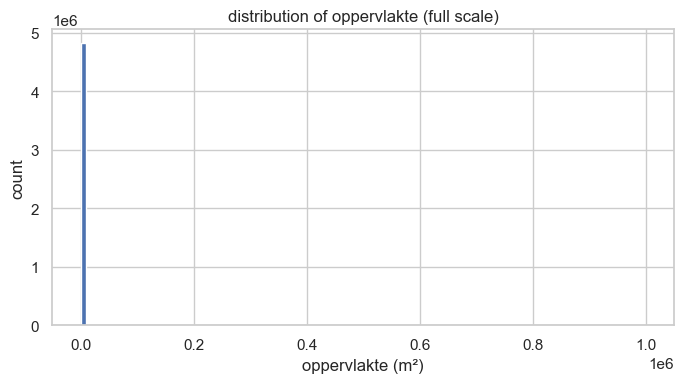

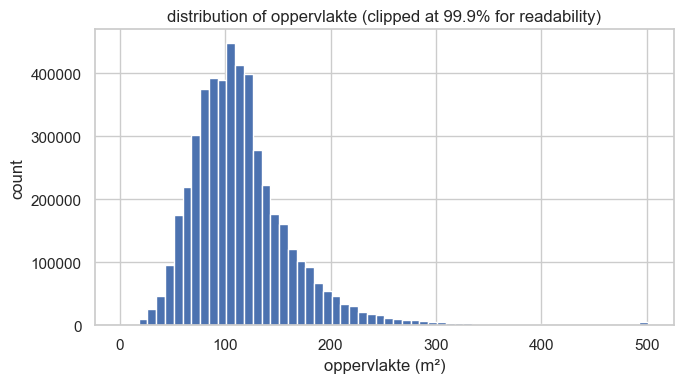

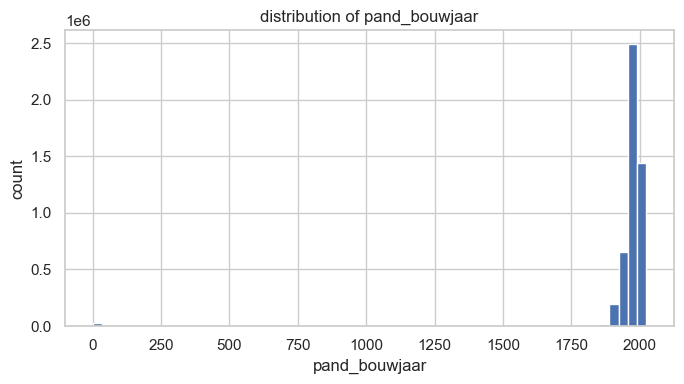

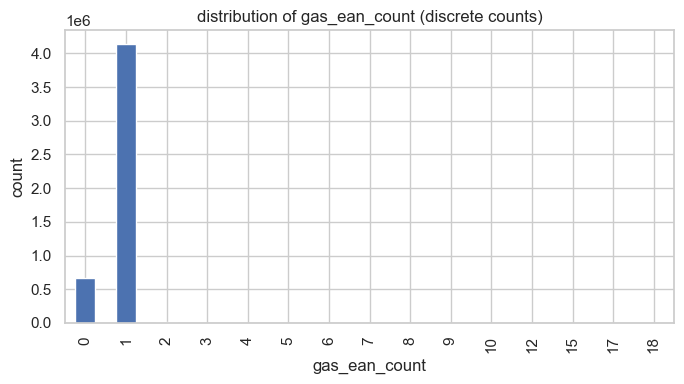

In [74]:
# ----------------------------
# 4.2A numeric distributions
# ----------------------------

# 1) oppervlakte (floor area): show full scale once to reveal extreme tail
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["oppervlakte"].dropna(), bins=100)
plt.title("distribution of oppervlakte (full scale)")
plt.xlabel("oppervlakte (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 2) oppervlakte (floor area): clipped view for readability only
upper_99 = df_dwelling["oppervlakte"].quantile(0.999)

plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["oppervlakte"].dropna().clip(upper=upper_99), bins=60)
plt.title("distribution of oppervlakte (clipped at 99.9% for readability)")
plt.xlabel("oppervlakte (m²)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 3) pand_bouwjaar: normal histogram
plt.figure(figsize=(7, 4))
plt.hist(df_dwelling["pand_bouwjaar"].dropna(), bins=60)
plt.title("distribution of pand_bouwjaar")
plt.xlabel("pand_bouwjaar")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# 4) gas_ean_count: discrete count plot (not a histogram)
vc_gas = df_dwelling["gas_ean_count"].value_counts().sort_index()

plt.figure(figsize=(7, 4))
vc_gas.plot(kind="bar")
plt.title("distribution of gas_ean_count (discrete counts)")
plt.xlabel("gas_ean_count")
plt.ylabel("count")
plt.tight_layout()
plt.show()

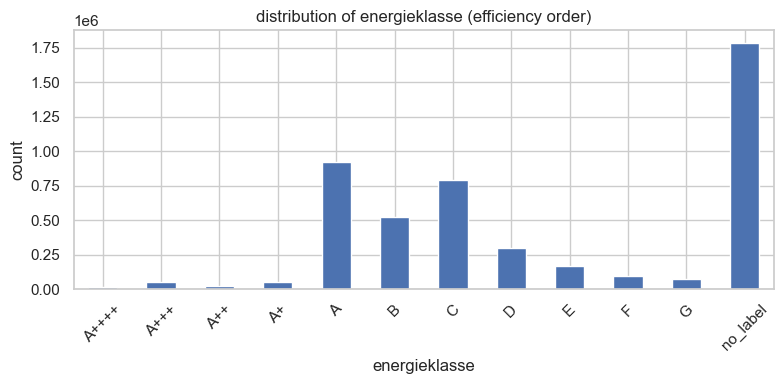

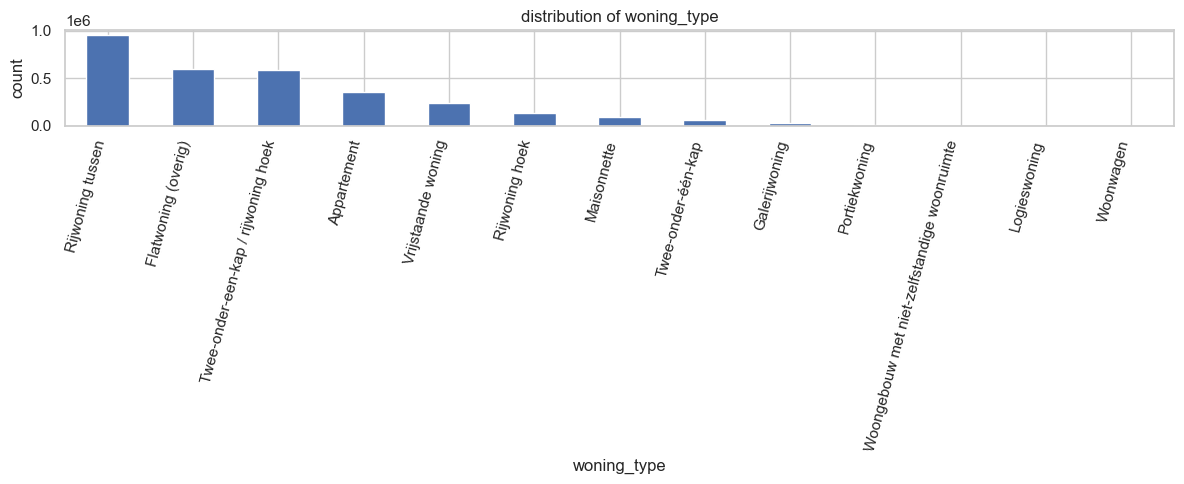

In [75]:
# ----------------------------
# 4.2B categorical distributions
# ----------------------------

# energieklasse bar plot (efficiency order, includes no_label)
plt.figure(figsize=(8, 4))
counts_label.reindex(label_order).plot(kind="bar")
plt.title("distribution of energieklasse (efficiency order)")
plt.xlabel("energieklasse")
plt.ylabel("count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# woning_type bar plot
plt.figure(figsize=(12, 5))
counts_type.plot(kind="bar")
plt.title("distribution of woning_type")
plt.xlabel("woning_type")
plt.ylabel("count")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

### 4.3 Structural diagnostics

This subsection identifies modeling-relevant structural properties and applies only transformations that are supported by clear empirical evidence.

We focus on four checks:

- 4.3A Gas connection structure (`gas_ean_count`)
- 4.3B Rare housing type categories (`woning_type`)
- 4.3C Floor area tail diagnostics and threshold decision (`oppervlakte`)
- 4.3D Construction year diagnostics

These checks improve stability and interpretability in later regression stages.

#### 4.3A Gas connection structure (`gas_ean_count`)

We first explore the distribution of gas connections and gas consumption to understand how dwellings access and use gas.  

The purpose of this section is to:

1. Determine if `gas_ean_count` behaves effectively as a binary variable or has meaningful variation.
2. Check for PC6-level vs dwelling-level variation.
3. Inspect gas consumption in dwellings with and without gas connections.
4. Explore whether a potential separation of heating vs cooking/hot water consumption could be feasible.

No assumptions or transformations will be made before inspecting the outputs.

We proceed in structured diagnostic steps.

=== gas_ean_count distribution ===


gas_ean_count
0      673455
1     4133488
2       10816
3        2125
4         247
5          42
6           9
7          14
8           2
9           5
10          2
12          2
15          1
17          1
18          1
Name: count, dtype: int64


Number of unique gas_ean_count values: 15

Share of PC6s with more than one unique gas_ean_count value:
0.21536730851750624

Distribution of unique gas_ean_count values per PC6:


gas_ean_count
1    202968
2     50290
3      4834
4       544
5        38
6         3
7         1
8         1
Name: count, dtype: int64


Gas consumption statistics for dwellings with gas_ean_count = 0:


count    673455.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: p6_gasm3_2023, dtype: float64


Share of dwellings with gas_ean_count = 0 but positive gas consumption:
0.0


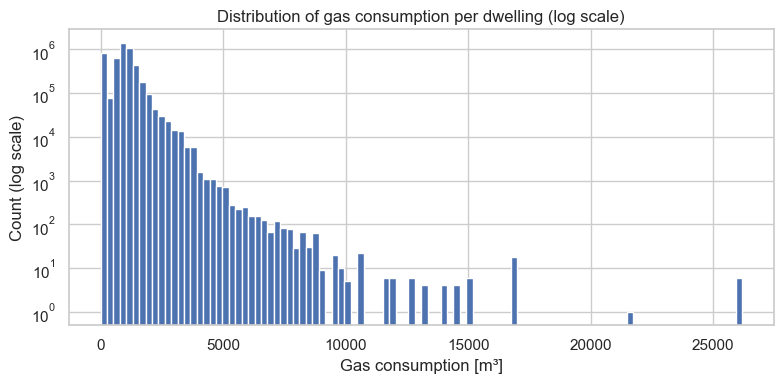

In [76]:
# ----------------------------
# 4.3A Gas connection diagnostics
# ----------------------------

# Step 1: Inspect overall distribution of gas connections
print("=== gas_ean_count distribution ===")
vc_gas = df_dwelling["gas_ean_count"].value_counts().sort_index()
display(vc_gas)

print("\nNumber of unique gas_ean_count values:", df_dwelling["gas_ean_count"].nunique())

# Step 2: Check variation within PC6 areas
pc6_variation = df_dwelling.groupby("postcode")["gas_ean_count"].nunique()

print("\nShare of PC6s with more than one unique gas_ean_count value:")
print((pc6_variation > 1).mean())

print("\nDistribution of unique gas_ean_count values per PC6:")
display(pc6_variation.value_counts().sort_index())

# Step 3: Examine gas consumption when gas_ean_count = 0
gas_zero_stats = df_dwelling.loc[
    df_dwelling["gas_ean_count"] == 0,
    "p6_gasm3_2023"
].describe()

print("\nGas consumption statistics for dwellings with gas_ean_count = 0:")
display(gas_zero_stats)

# Step 4: Inspect dwellings with gas_ean_count = 0 but positive gas consumption
inconsistent = (
    (df_dwelling["gas_ean_count"] == 0) &
    (df_dwelling["p6_gasm3_2023"] > 0)
)

print("\nShare of dwellings with gas_ean_count = 0 but positive gas consumption:")
print(inconsistent.mean())

# Step 5: Plot histogram of gas consumption to explore possible separation of heating vs cooking/hot water
plt.figure(figsize=(8, 4))
plt.hist(df_dwelling["p6_gasm3_2023"].dropna(), bins=100, log=True)
plt.title("Distribution of gas consumption per dwelling (log scale)")
plt.xlabel("Gas consumption [m³]")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

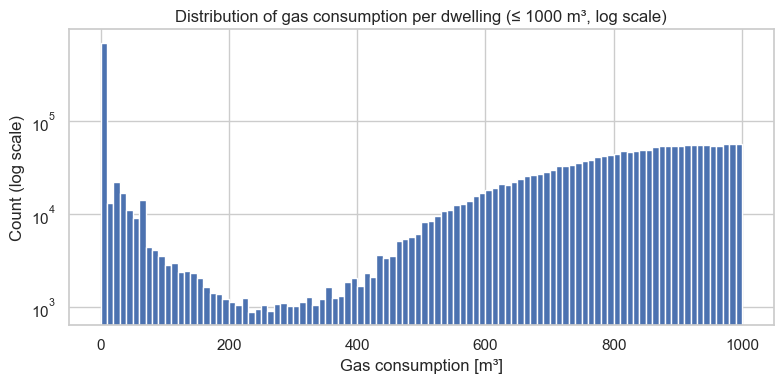

In [77]:
# Step 5: Plot histogram of gas consumption (clipped at 1000 m³ for readability)

gas_plot = df_dwelling["p6_gasm3_2023"].dropna()

# keep only values up to 1000 for visualization
gas_plot = gas_plot[gas_plot <= 1000]

plt.figure(figsize=(8, 4))
plt.hist(gas_plot, bins=100, log=True)
plt.title("Distribution of gas consumption per dwelling (≤ 1000 m³, log scale)")
plt.xlabel("Gas consumption [m³]")
plt.ylabel("Count (log scale)")
plt.tight_layout()
plt.show()

#### Final gas connection variable consideration

The diagnostic analysis confirms that `gas_ean_count` is concentrated at values **0 and 1**, with only a tiny fraction of dwellings having multiple gas connections. Most dwellings either have no gas or a single gas connection.

Inspection of gas consumption (`p6_gasm3_2023`) shows that dwellings with `gas_ean_count = 0` consistently consume **zero gas**, with no exceptions. This indicates that zero counts accurately represent the **absence of a gas connection**.

Variation of `gas_ean_count` within PC6 areas exists but is limited: most PC6s are homogeneous, and only ~21% have more than one unique value.  

Because the histogram of gas consumption does not reveal clear modes separating cooking/hot water from heating demand, creating a separate `gas_heated` variable from the current data would be **arbitrary and potentially misleading**.  

**Conclusion:** For now, the structural information about gas availability is best captured using a **binary indicator**:

- **`has_gas = True`** if `gas_ean_count > 0`  
- **`has_gas = False`** if `gas_ean_count = 0`

This variable reliably reflects the presence of gas in the dwelling without introducing assumptions about heating versus non-heating gas usage.

In [78]:
# ----------------------------
# create binary gas connection indicator
# ----------------------------

df_dwelling["has_gas"] = df_dwelling["gas_ean_count"].fillna(0) > 0

print("share of dwellings with gas connection (has_gas=True):")
print(round(df_dwelling["has_gas"].mean(), 4))

share of dwellings with gas connection (has_gas=True):
0.8603


#### 4.3B Rare housing type categories (`woning_type`)

Very rare housing categories may create unstable estimates in later modelling stages.  
When PC6 compositions are computed, categories with extremely small sample sizes can produce noisy or unreliable shares.

To diagnose this, we first examine the structural characteristics and sample size of each housing type.

The objective of this step is to:

- understand structural differences between housing types
- detect extremely rare categories
- determine whether any categories should be removed from the modelling dataset

In [79]:
# ----------------------------
# 4.3B woning_type structural comparison
# ----------------------------

type_structure = (
    df_dwelling
    .groupby("woning_type")[["oppervlakte", "pand_bouwjaar"]]
    .agg(["mean", "median", "count"])
)

display(type_structure)

oppervlakte                 \
                                                   mean median   count   
woning_type                                                              
Appartement                                   73.975433   73.0  349408   
Flatwoning (overig)                           73.921175   72.0  596385   
Galerijwoning                                 68.687315   70.0   27766   
Logieswoning                                 104.896907   93.0      97   
Maisonnette                                   88.835303   86.0   86917   
Portiekwoning                                 68.922706   68.0    9742   
Rijwoning hoek                               111.574327  107.0  131385   
Rijwoning tussen                             110.026657  108.0  955361   
Twee-onder-een-kap / rijwoning hoek          128.817983  124.0  583731   
Twee-onder-één-kap                           138.627003  137.0   62770   
Vrijstaande woning                           192.025511  180.0  232606   
Woongebouw met niet-zelfstandige woonruimte   64.753012   33.0     166   
Woonwagen                                    101.454545   79.0      11   

                                            pand_bouwjaar                  
                                                     mean  median   count  
woning_type                                                                
Appartement                                   1969.930743  1974.0  349408  
Flatwoning (overig)                           1975.118787  1975.0  596385  
Galerijwoning                                 1981.333790  1976.0   27766  
Logieswoning                                  1850.072165  1975.0      97  
Maisonnette                                   1967.642694  1977.0   86917  
Portiekwoning                                 1964.512626  1962.0    9742  
Rijwoning hoek                                1970.210709  1975.0  131385  
Rijwoning tussen                              1976.355324  1978.0  955361  
Twee-onder-een-kap / rijwoning hoek           1979.765558  1981.0  583731  
Twee-onder-één-kap                            1971.997101  1980.0   62770  
Vrijstaande woning                            1978.132692  1988.0  232606  
Woongebouw met niet-zelfstandige woonruimte   1969.391566  1986.0     166  
Woonwagen                                     1807.727273  1987.0      11

To further examine structural similarities between housing types, we compute a standardized structural profile and visualize it using hierarchical clustering.

This diagnostic helps identify which housing types share similar structural characteristics such as:

- floor area
- construction year
- gas connection presence

The clustering is used only as an exploratory diagnostic and not as the sole basis for modelling decisions.

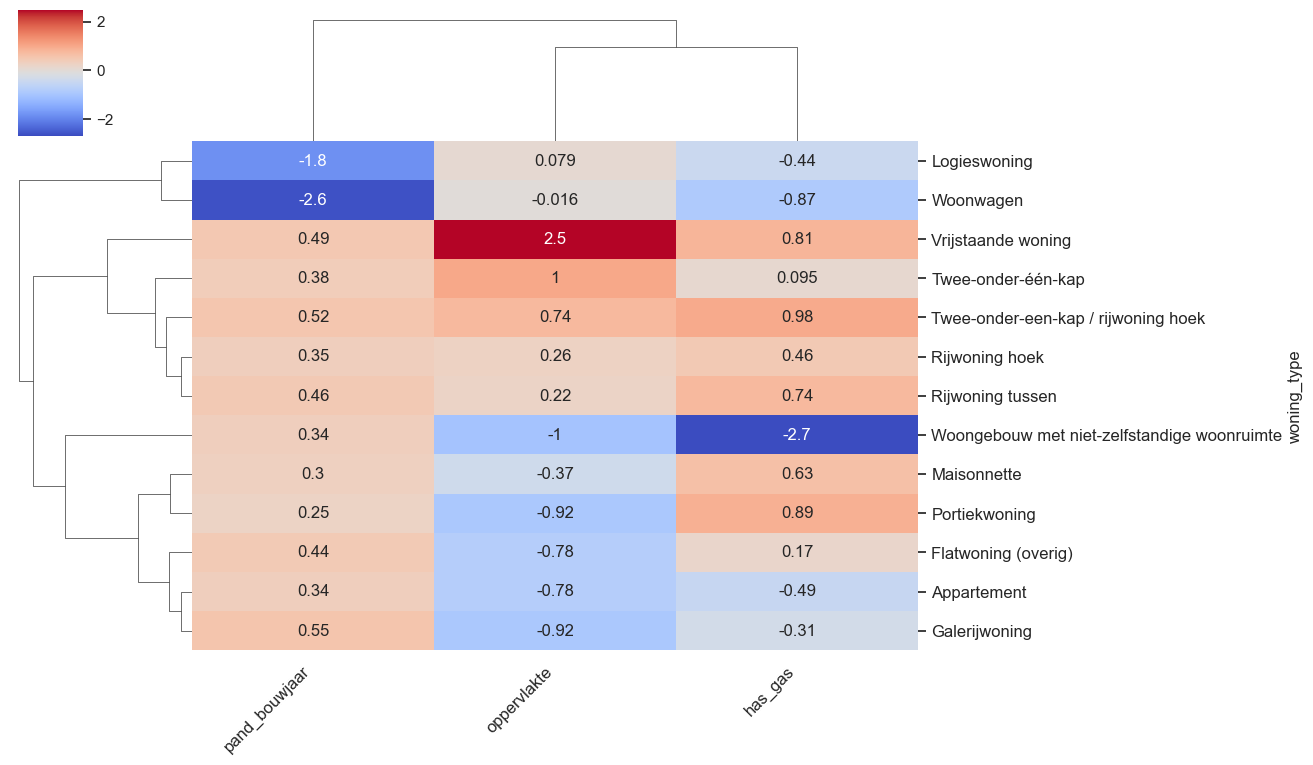

In [80]:
# ----------------------------
# Structural profile per woning_type
# ----------------------------

cols = ["oppervlakte", "pand_bouwjaar", "has_gas"]

# ensure numeric types
for c in ["oppervlakte", "pand_bouwjaar"]:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# convert boolean to integer
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

# compute mean structural profile
profile = df_dwelling.groupby("woning_type")[cols].mean()

# standardize variables
profile_scaled = (profile - profile.mean()) / profile.std()

# clustered heatmap
g = sns.clustermap(
    profile_scaled,
    cmap="coolwarm",
    metric="euclidean",
    method="ward",
    figsize=(13,7),
    annot=True
)

plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=12)
plt.setp(g.ax_heatmap.get_yticklabels(), fontsize=12)

plt.show()

In [81]:
# ----------------------------
# Diagnostic: PC6 affected by rare housing types
# ----------------------------

rare_types = [
    "Logieswoning",
    "Woongebouw met niet-zelfstandige woonruimte",
    "Woonwagen"
]

# PC6 that contain at least one rare type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["woning_type"].isin(rare_types),
    "postcode"
].unique()

n_pc6_with_rare = len(pc6_with_rare)
total_pc6 = df_dwelling["postcode"].nunique()

print("PC6 containing rare dwelling types:", n_pc6_with_rare)
print("Total PC6:", total_pc6)
print("Share of PC6 affected:", round(n_pc6_with_rare / total_pc6, 4))


# ----------------------------
# How many dwellings would be removed?
# ----------------------------

rows_in_pc6_with_rare = df_dwelling["postcode"].isin(pc6_with_rare).sum()
total_rows = len(df_dwelling)

print("\nDwellings located in those PC6:", rows_in_pc6_with_rare)
print("Total dwellings:", total_rows)
print("Share of dwellings affected:", round(rows_in_pc6_with_rare / total_rows, 4))


# ----------------------------
# How many rare dwellings themselves?
# ----------------------------

rare_rows = df_dwelling["woning_type"].isin(rare_types).sum()

print("\nRare dwelling rows only:", rare_rows)
print("Share of rare dwellings:", round(rare_rows / total_rows, 6))

PC6 containing rare dwelling types: 116
Total PC6: 258679
Share of PC6 affected: 0.0004

Dwellings located in those PC6: 2705
Total dwellings: 4820210
Share of dwellings affected: 0.0006

Rare dwelling rows only: 274
Share of rare dwellings: 5.7e-05


#### Final modelling decision

The structural comparison and clustering diagnostics reveal that three housing types are extremely rare within the national dataset:

- **Logieswoning**
- **Woongebouw met niet-zelfstandige woonruimte**
- **Woonwagen**

These categories together represent a negligible share of the housing stock and occur in only a very small number of postcode areas.

Because the energy variables in the dataset are defined at **PC6 level**, removing only the individual dwelling rows would create an inconsistency between the structural composition of a PC6 and its associated energy totals.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing these rare dwelling types are removed from the modelling dataset**.

This exclusion affects only a very small fraction of the dataset and therefore does not materially alter the representation of the Dutch residential housing stock.

The analysis proceeds with the remaining PC6 areas, which represent virtually the entire residential building stock.

In [82]:
# ----------------------------
# remove PC6 areas containing extremely rare housing types
# ----------------------------

# identify PC6 that contain any rare dwelling type
pc6_with_rare = df_dwelling.loc[
    df_dwelling["woning_type"].isin(rare_types),
    "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_rare)
].copy()

print("Remaining PC6:", df_dwelling["postcode"].nunique())
print("Remaining dwellings:", len(df_dwelling))

print("\nRemaining housing types:")
print(df_dwelling["woning_type"].value_counts())

Remaining PC6: 258563
Remaining dwellings: 4817505

Remaining housing types:
woning_type
Rijwoning tussen                       955165
Flatwoning (overig)                    596069
Twee-onder-een-kap / rijwoning hoek    583623
Appartement                            349090
Vrijstaande woning                     232362
Rijwoning hoek                         131356
Maisonnette                             86898
Twee-onder-één-kap                      62750
Galerijwoning                           27748
Portiekwoning                            9726
Name: count, dtype: int64


#### 4.3C Floor area tail diagnostics and threshold decision (`oppervlakte`)

The floor area distribution contains extreme values that strongly distort scale.
We treat percentiles as diagnostic evidence, and we choose thresholds using a hybrid approach:

- Percentiles to understand where the bulk of the housing stock lies
- Direct inspection to detect sentinel or implausible magnitudes
- Candidate threshold testing to quantify how much data is affected

Based on the diagnostics in Sections 4.3C1–4.3C6, floor area limits were defined to remove implausible observations while preserving realistic housing variability.

In [83]:
# 4.3C1 inspect upper tail values directly (structural plausibility check)

# ---extremely large values (>2000 m²)
extreme_threshold = 2000

extreme_values = (
    df_dwelling[df_dwelling["oppervlakte"] > extreme_threshold]["oppervlakte"]
    .value_counts()
    .head(20)
)

print(f"most frequent floor area values above {extreme_threshold} m²:")
display(extreme_values)


# ---large but potentially plausible band (1000–2000 m²)
large_band = (
    df_dwelling[
        (df_dwelling["oppervlakte"] > 1000) &
        (df_dwelling["oppervlakte"] <= 2000)
    ]["oppervlakte"]
    .value_counts()
    .head(20)
)

print("most frequent floor area values between 1000 and 2000 m²:")
display(large_band)


# --- diagnostic summary
n_above_1000 = (df_dwelling["oppervlakte"] > 1000).sum()
share_above_1000 = 100 * n_above_1000 / len(df_dwelling)

print(f"total dwellings above 1000 m²: {n_above_1000}")
print(f"share of dataset above 1000 m²: {share_above_1000:.6f}%")

most frequent floor area values above 2000 m²:


oppervlakte
999999.0    5
2003.0      3
99999.0     2
9999.0      2
2993.0      2
6745.0      2
13388.0     2
110171.0    2
2835.0      2
2487.0      1
21867.0     1
6214.0      1
7440.0      1
2202.0      1
117615.0    1
9288.0      1
3298.0      1
2163.0      1
4920.0      1
4518.0      1
Name: count, dtype: int64

most frequent floor area values between 1000 and 2000 m²:


oppervlakte
1092.0    5
1021.0    3
1009.0    3
1172.0    3
1019.0    3
1135.0    3
1128.0    3
1111.0    3
1039.0    3
1158.0    3
1072.0    3
1081.0    3
1935.0    3
1031.0    2
1105.0    2
1051.0    2
1010.0    2
1195.0    2
1107.0    2
1138.0    2
Name: count, dtype: int64

total dwellings above 1000 m²: 456
share of dataset above 1000 m²: 0.009465%


In [84]:
# 4.3C2 candidate upper limits and removal shares

candidate_upper_limits = [800, 1000, 1500, 2000]

print("removal share for candidate upper limits:")
for limit in candidate_upper_limits:
    removed_share = (df_dwelling["oppervlakte"] > limit).mean() * 100
    print(f"upper limit {limit} m² → {removed_share:.5f}% removed")

removal share for candidate upper limits:
upper limit 800 m² → 0.01800% removed
upper limit 1000 m² → 0.00947% removed
upper limit 1500 m² → 0.00326% removed
upper limit 2000 m² → 0.00189% removed


In [85]:
# 4.3C3 inspect lower tail values directly (structural plausibility check)

# ---extremely small values (<10 m²)
extreme_lower_threshold = 10

extreme_lower_values = (
    df_dwelling[df_dwelling["oppervlakte"] < extreme_lower_threshold]["oppervlakte"]
    .value_counts()
)

print(f"most frequent floor area values below {extreme_lower_threshold} m²:")
display(extreme_lower_values)


# ---small but potentially plausible band (10–20 m²)
small_band = (
    df_dwelling[
        (df_dwelling["oppervlakte"] >= 10) &
        (df_dwelling["oppervlakte"] < 20)
    ]["oppervlakte"]
    .value_counts()
)

print("most frequent floor area values between 10 and 20 m²:")
display(small_band)


# --- diagnostic summary
n_below_10 = (df_dwelling["oppervlakte"] < 10).sum()
share_below_10 = 100 * n_below_10 / len(df_dwelling)

print(f"total dwellings below 10 m²: {n_below_10}")
print(f"share of dataset below 10 m²: {share_below_10:.6f}%")

most frequent floor area values below 10 m²:


oppervlakte
1.0    151
5.0      3
8.0      2
9.0      2
2.0      1
7.0      1
Name: count, dtype: int64

most frequent floor area values between 10 and 20 m²:


oppervlakte
19.0    729
18.0    673
15.0    314
17.0    307
16.0    139
14.0     50
11.0     46
13.0     45
12.0     32
10.0     26
Name: count, dtype: int64

total dwellings below 10 m²: 160
share of dataset below 10 m²: 0.003321%


In [86]:
# 4.3C4 candidate lower limits and removal shares

candidate_lower_limits = [5, 10, 15, 20]

print("removal share for candidate lower limits:")
for limit in candidate_lower_limits:
    removed_share = (df_dwelling["oppervlakte"] < limit).mean() * 100
    print(f"lower limit {limit} m² → {removed_share:.6f}% removed")

removal share for candidate lower limits:
lower limit 5 m² → 0.003155% removed
lower limit 10 m² → 0.003321% removed
lower limit 15 m² → 0.007452% removed
lower limit 20 m² → 0.052330% removed


In [87]:
# ----------------------------
# 4.3C5 diagnostic: effect of removing whole PC6 vs only outlier rows
# ----------------------------

lower_limit = 10
upper_limit = 1000

# dwellings outside the accepted floor area range
area_outlier_mask = (
    (df_dwelling["oppervlakte"] < lower_limit) |
    (df_dwelling["oppervlakte"] > upper_limit)
)

# PC6 containing at least one floor-area outlier
pc6_with_area_outliers = df_dwelling.loc[area_outlier_mask, "postcode"].unique()

n_pc6_total = df_dwelling["postcode"].nunique()
n_rows_total = len(df_dwelling)

n_outlier_rows = area_outlier_mask.sum()
share_outlier_rows = n_outlier_rows / n_rows_total

n_pc6_with_outliers = len(pc6_with_area_outliers)
share_pc6_with_outliers = n_pc6_with_outliers / n_pc6_total

rows_in_affected_pc6 = df_dwelling["postcode"].isin(pc6_with_area_outliers).sum()
share_rows_in_affected_pc6 = rows_in_affected_pc6 / n_rows_total

print("=== Floor area outlier diagnostic ===")
print(f"Outlier dwellings only: {n_outlier_rows}")
print(f"Share of outlier dwellings: {share_outlier_rows:.6%}")

print(f"\nPC6 containing at least one area outlier: {n_pc6_with_outliers}")
print(f"Share of PC6 affected: {share_pc6_with_outliers:.6%}")

print(f"\nDwellings located in those affected PC6: {rows_in_affected_pc6}")
print(f"Share of dwellings affected if whole PC6 were removed: {share_rows_in_affected_pc6:.6%}")

=== Floor area outlier diagnostic ===
Outlier dwellings only: 616
Share of outlier dwellings: 0.012787%

PC6 containing at least one area outlier: 518
Share of PC6 affected: 0.200338%

Dwellings located in those affected PC6: 11362
Share of dwellings affected if whole PC6 were removed: 0.235848%


#### Final floor area threshold decision

Based on percentile diagnostics, direct inspection of extreme values, and evaluation of candidate thresholds, floor area limits were defined to identify implausible dwelling records while preserving realistic housing variability.

Inspection of the upper tail revealed rare sentinel-like values (e.g., 99,999 m² and 999,999 m²) and highly implausible dwelling sizes above 2000 m². Additional analysis showed that values between 1000–2000 m² were extremely sparse and did not represent a meaningful segment of the housing stock.

Lower-tail inspection identified a small number of dwellings with floor areas below 10 m², which are physically implausible for residential units and likely represent data artifacts or misclassified structures.

Because the energy variables in the dataset are defined at **PC6 level**, removing only the individual outlier dwellings would create an inconsistency between the structural composition of a PC6 and its associated energy totals.

To maintain internal consistency between the structural dataset and the PC6-level energy data, all **PC6 areas containing dwellings outside the accepted floor area range** are removed from the modelling dataset.

The adopted structural limits are:

- **Lower limit:** 10 m²  
- **Upper limit:** 1000 m²  

This exclusion affects only a very small share of the dataset and ensures that the remaining PC6 areas have structurally consistent housing composition and energy totals.

In [88]:
# 4.3C6 final structural thresholds (PC6-consistent filtering)

lower_limit = 10
upper_limit = 1000

n_pc6_before = df_dwelling["postcode"].nunique()
n_rows_before = len(df_dwelling)

# identify PC6 containing at least one floor-area outlier
area_outlier_mask = (
    (df_dwelling["oppervlakte"] < lower_limit) |
    (df_dwelling["oppervlakte"] > upper_limit)
)

pc6_with_area_outliers = df_dwelling.loc[
    area_outlier_mask, "postcode"
].unique()

# remove those PC6 entirely
df_dwelling = df_dwelling[
    ~df_dwelling["postcode"].isin(pc6_with_area_outliers)
].copy()

n_pc6_after = df_dwelling["postcode"].nunique()
n_rows_after = len(df_dwelling)

print("after PC6-consistent floor area filtering")
print("remaining PC6:", n_pc6_after)
print("remaining rows:", n_rows_after)

print("\nPC6 removed:", n_pc6_before - n_pc6_after)
print("dwellings removed:", n_rows_before - n_rows_after)

print(f"\nshare of PC6 removed: {(1 - n_pc6_after / n_pc6_before) * 100:.5f}%")
print(f"share of dwellings removed: {(1 - n_rows_after / n_rows_before) * 100:.5f}%")

after PC6-consistent floor area filtering
remaining PC6: 258045
remaining rows: 4806143

PC6 removed: 518
dwellings removed: 11362

share of PC6 removed: 0.20034%
share of dwellings removed: 0.23585%


#### 4.3D Construction year diagnostics and threshold decision (`pand_bouwjaar`)

Construction year is retained during minimal cleaning so that lower-tail values can be diagnosed before applying a structural threshold.

We inspect the lower tail of `pand_bouwjaar` to identify clearly implausible or administrative values and then apply a final lower bound supported by the observed distribution.

In [89]:
# 4.3D1 construction year diagnostics

print("minimum bouwjaar:", df_dwelling["pand_bouwjaar"].min())
print(df_dwelling["pand_bouwjaar"].describe(percentiles=[0.001, 0.01, 0.05]))

print("most frequent bouwjaar values below 1700:")
display(
    df_dwelling.loc[df_dwelling["pand_bouwjaar"] < 1700, "pand_bouwjaar"]
    .value_counts()
    .head(20)
)

print("Construction year values between 1 and 999:")

display(
    df_dwelling.loc[
        (df_dwelling["pand_bouwjaar"] >= 1) &
        (df_dwelling["pand_bouwjaar"] < 1000),
        "pand_bouwjaar"
    ]
    .value_counts()
    .sort_index()
)

minimum bouwjaar: 0
count    4.806143e+06
mean     1.966671e+03
std      1.376194e+02
min      0.000000e+00
0.1%     0.000000e+00
1%       1.889000e+03
5%       1.922000e+03
max      2.024000e+03
Name: pand_bouwjaar, dtype: float64
most frequent bouwjaar values below 1700:


pand_bouwjaar
0       22421
1650      296
1600      116
1450       84
1681       76
1660       69
1625       59
1592       51
1680       39
1675       37
1666       36
1690       30
1670       29
1005       29
1350       28
1683       24
1659       24
1671       24
1616       22
1685       21
Name: count, dtype: int64

Construction year values between 1 and 999:


Series([], Name: count, dtype: int64)

#### Final construction year threshold decision

Inspection of the lower tail revealed a concentration of entries with a construction year equal to **0**, which represent administrative placeholders rather than valid construction dates. These records do not correspond to real building years and therefore cannot be interpreted meaningfully in structural analysis.

To address this issue while preserving the historical housing stock, only observations with **`pand_bouwjaar = 0`** are removed. All other registry construction years are retained, including very early historical values, as they represent valid entries in the national building registry and do not distort the statistical distribution of the dataset.

In [90]:
# 4.3D2 final construction year threshold

n_before = len(df_dwelling)

# lower construction year limit
# set to 1 to only remove the administrative artifact (year = 0)
year_lower_limit = 1

df_dwelling = df_dwelling[
    df_dwelling["pand_bouwjaar"] >= year_lower_limit
].copy()

n_after = len(df_dwelling)

print("after construction year filtering")
print("rows:", n_after)
print(f"share removed by bouwjaar filtering: {(1 - n_after / n_before) * 100:.5f}%")

after construction year filtering
rows: 4783722
share removed by bouwjaar filtering: 0.46651%


### 4.4 Correlation analysis between dwelling features

This section quantifies statistical relationships between dwelling characteristics, building directly on the previous steps:

- **4.1 Descriptive statistics** confirmed that each feature has meaningful variation.
- **4.2 Distribution visualization** revealed skewness, heavy tails, and category imbalance.
- **4.3 Structural diagnostics** handled artifacts (especially in `oppervlakte`) and clarified how variables behave. In particular, the gas connection variable was shown to behave largely as a binary structural characteristic, so the derived indicator `has_gas` is used in the correlation analysis that follows.

Because the dataset includes mixed variable types, no single classical association coefficient is appropriate for all variable pairs. Therefore, associations are evaluated using measures matched to variable type:

- **Spearman correlation** for numeric-numeric relationships
- **Cramér’s V** for categorical-categorical relationships
- **Correlation ratio (η)** for categorical-numeric relationships

After evaluating each pair type separately, a **mixed-type association matrix** is constructed to provide a unified overview of all relationships between dwelling features.

Finally, a **Variance Inflation Factor (VIF)** diagnostic is performed to detect multicollinearity within the predictor set used later in regression modelling.

#### 4.4A Prepare analysis variables

The association analysis uses a set of structural dwelling variables describing building characteristics and energy-related attributes.

Numeric variables:
• `oppervlakte` – dwelling floor area  
• `pand_bouwjaar` – construction year  

Categorical variables:
• `energieklasse` – energy performance label  
• `woning_type` – dwelling type  
• `has_gas` – indicator of gas connection presence  

Energy labels are treated as **categorical variables**, including the category `no_label`, which represents dwellings without a registered energy label.

The variable `has_gas` is derived from `gas_ean_count` and used as a binary structural indicator.

In [91]:
# ----------------------------
# 4.4A Prepare analysis variables
# ----------------------------

# numeric features used in association analysis
num_cols = ["oppervlakte", "pand_bouwjaar"]

# categorical features used in association analysis
cat_cols = ["energieklasse", "woning_type", "has_gas"]

# ensure has_gas exists
if "has_gas" not in df_dwelling.columns:
    df_dwelling["has_gas"] = df_dwelling["gas_ean_count"].fillna(0) > 0

# ensure energieklasse remains an explicit categorical variable
label_order = [
    "A++++", "A+++", "A++", "A+",
    "A", "B", "C", "D", "E", "F", "G",
    "no_label"
]

df_dwelling["energieklasse"] = pd.Categorical(
    df_dwelling["energieklasse"],
    categories=label_order,
    ordered=False
)

# quick sanity checks
print("sanity checks")
print("rows:", len(df_dwelling))
print("unique pc6:", df_dwelling["postcode"].nunique())
print("share has_gas = true:", round(df_dwelling["has_gas"].mean(), 4))
print("share energieklasse == 'no_label':",
      round((df_dwelling["energieklasse"] == "no_label").mean(), 4))
print("\nenergieklasse counts:")
display(df_dwelling["energieklasse"].value_counts(dropna=False).sort_index())

sanity checks
rows: 4783722
unique pc6: 257669
share has_gas = true: 0.8649
share energieklasse == 'no_label': 0.3681

energieklasse counts:


energieklasse
A++++         17588
A+++          49387
A++           26667
A+            52588
A            922046
B            524431
C            789993
D            298436
E            170670
F             94603
G             76435
no_label    1760878
Name: count, dtype: int64

#### 4.4B Numeric structural correlations

Relationships between numeric dwelling characteristics are evaluated using **Spearman rank correlation**.

Spearman correlation is chosen because several variables exhibit skewed distributions and potential outliers, making a rank-based measure more robust than Pearson correlation.

The analysis focuses on:

• `oppervlakte` – dwelling floor area  
• `pand_bouwjaar` – construction year

The resulting matrix summarizes the strength and direction of monotonic relationships between these structural variables.

,oppervlakte,pand_bouwjaar
oppervlakte,1.000000,0.235873
pand_bouwjaar,0.235873,1.000000


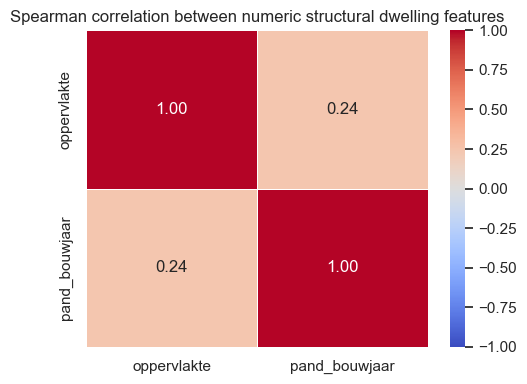

In [92]:
# ----------------------------
# 4.4B Spearman correlation matrix
# ----------------------------

spearman_cols = [
    "oppervlakte",
    "pand_bouwjaar"
]

corr_spearman = df_dwelling[spearman_cols].corr(method="spearman")

display(corr_spearman)

plt.figure(figsize=(5, 4))
sns.heatmap(
    corr_spearman,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Spearman correlation between numeric structural dwelling features")
plt.tight_layout()
plt.show()

#### 4.4C Categorical–categorical associations (Cramér’s V)

Associations between categorical dwelling characteristics are measured using **Cramér’s V**, which is based on the chi-squared statistic and provides a normalized measure of association between categorical variables.

The categorical variables considered are:

• `energieklasse` – energy performance label  
• `woning_type` – dwelling type  
• `has_gas` – gas connection indicator

Cramér’s V ranges from **0 (no association)** to **1 (perfect association)**.

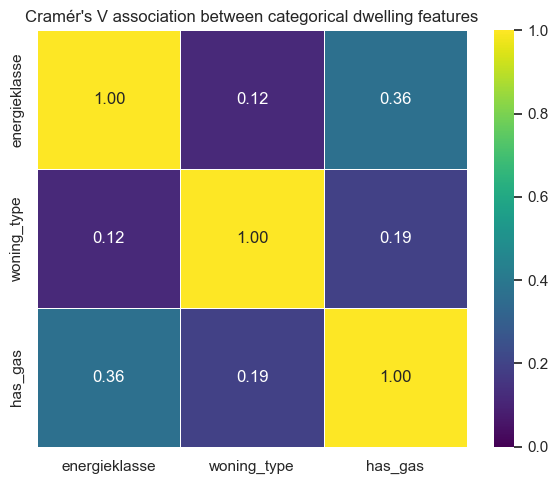

In [93]:
# ----------------------------
# 4.4C Cramér's V association matrix
# ----------------------------

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Compute Cramér's V statistic for categorical-categorical association.
    """
    contingency_table = pd.crosstab(x, y)

    if contingency_table.size == 0:
        return np.nan

    chi2 = chi2_contingency(contingency_table)[0]
    n = contingency_table.sum().sum()
    r, k = contingency_table.shape

    denom = min(r - 1, k - 1)

    if denom <= 0 or n == 0:
        return np.nan

    return np.sqrt((chi2 / n) / denom)


# categorical variables to analyze
cat_for_v = ["energieklasse", "woning_type", "has_gas"]

# create empty matrix
V = pd.DataFrame(index=cat_for_v, columns=cat_for_v, dtype=float)

# compute pairwise Cramér's V
for i in cat_for_v:
    for j in cat_for_v:
        if i == j:
            V.loc[i, j] = 1.0
        else:
            V.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

# ----------------------------
# Cramér's V heatmap
# ----------------------------

plt.figure(figsize=(6,5))

sns.heatmap(
    V,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    vmin=0,
    vmax=1,
    linewidths=0.5
)

plt.title("Cramér's V association between categorical dwelling features")
plt.tight_layout()
plt.show()

#### 4.4D Categorical–numeric associations (correlation ratio η)

Relationships between categorical variables and numeric variables are evaluated using the **correlation ratio (η)**.

The correlation ratio measures how strongly the distribution of a numeric variable differs across categories of a categorical variable.

In this analysis, it is used to evaluate how variables such as dwelling type, energy label, or gas connection presence relate to numeric structural characteristics like floor area or construction year.

The statistic ranges from **0 (no association)** to **1 (perfect association)**.

,oppervlakte,pand_bouwjaar
woning_type,0.690216,0.092794
energieklasse,0.216555,0.468057
has_gas,0.067754,0.244161


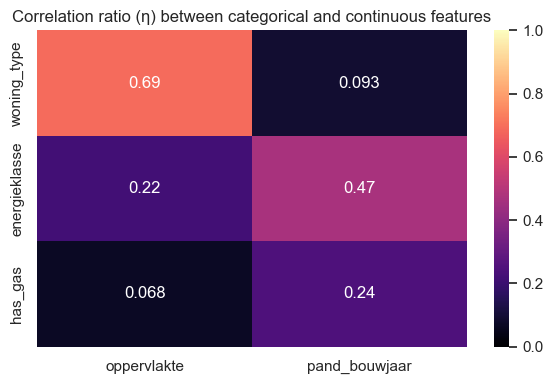

In [94]:
# ----------------------------
# 4.4D Correlation ratio (η)
# ----------------------------

def correlation_ratio(categories, measurements):
    """
    Compute correlation ratio (η) for categorical → continuous association.
    """
    valid = pd.notna(categories) & pd.notna(measurements)
    categories = pd.Series(categories)[valid]
    measurements = pd.Series(measurements)[valid].astype(float)

    if len(measurements) == 0:
        return np.nan

    codes, uniques = pd.factorize(categories)
    cat_num = len(uniques)

    if cat_num <= 1:
        return np.nan

    y_avg = np.zeros(cat_num)
    n = np.zeros(cat_num)

    for i in range(cat_num):
        cat_measures = measurements[codes == i]
        n[i] = len(cat_measures)
        if len(cat_measures) > 0:
            y_avg[i] = np.mean(cat_measures)

    y_total = np.sum(y_avg * n) / np.sum(n)

    numerator = np.sum(n * (y_avg - y_total) ** 2)
    denominator = np.sum((measurements - y_total) ** 2)

    if denominator == 0:
        return np.nan

    return np.sqrt(numerator / denominator)


cont_vars = ["oppervlakte", "pand_bouwjaar"]
cat_vars = ["woning_type", "energieklasse", "has_gas"]

eta_matrix = pd.DataFrame(index=cat_vars, columns=cont_vars)

for cat in cat_vars:
    for cont in cont_vars:
        eta_matrix.loc[cat, cont] = correlation_ratio(
            df_dwelling[cat],
            df_dwelling[cont]
        )

eta_matrix = eta_matrix.astype(float)

display(eta_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(eta_matrix, annot=True, cmap="magma", vmin=0, vmax=1)
plt.title("Correlation ratio (η) between categorical and continuous features")
plt.tight_layout()
plt.show()

#### 4.4E Mixed association matrix

To provide a consolidated overview of dependencies between all dwelling characteristics, a mixed-type association matrix is constructed.

Different association measures are applied depending on the variable pair:

• Spearman correlation for numeric–numeric pairs  
• Cramér’s V for categorical–categorical pairs  
• Correlation ratio (η) for categorical–numeric pairs  

Because different statistics are used for different variable combinations, the resulting matrix does **not represent a single unified correlation coefficient** but rather a collection of appropriate association measures.

The matrix therefore serves as an exploratory diagnostic tool to identify potentially strong dependencies between structural dwelling variables.

,oppervlakte,pand_bouwjaar,energieklasse,woning_type,has_gas
oppervlakte,1.000000,0.235873,0.216555,0.690216,0.067754
pand_bouwjaar,0.235873,1.000000,0.468057,0.092794,0.244161
energieklasse,0.216555,0.468057,1.000000,0.115442,0.363538
woning_type,0.690216,0.092794,0.115442,1.000000,0.194012
has_gas,0.067754,0.244161,0.363538,0.194012,1.000000


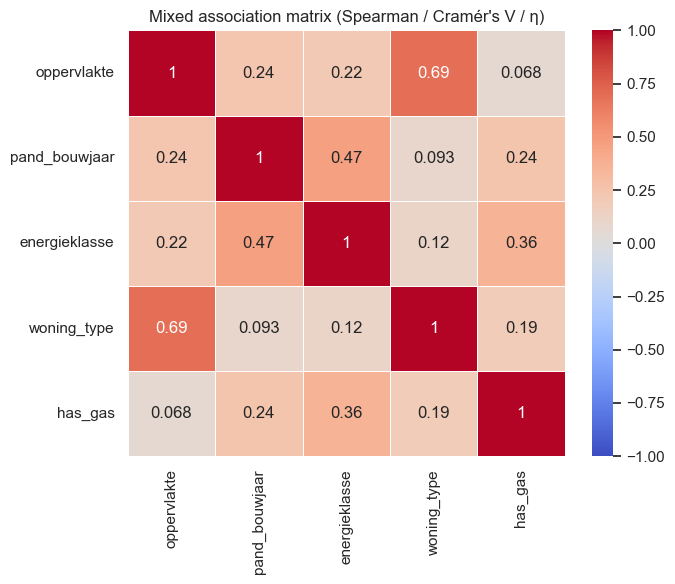

In [95]:
# ----------------------------
# 4.4E Mixed association matrix
# ----------------------------

num_vars = ["oppervlakte", "pand_bouwjaar"]
cat_vars = ["energieklasse", "woning_type", "has_gas"]

all_vars = num_vars + cat_vars

mixed_matrix = pd.DataFrame(index=all_vars, columns=all_vars, dtype=float)

for i in all_vars:
    for j in all_vars:

        if i == j:
            mixed_matrix.loc[i, j] = 1.0

        # numeric-numeric → Spearman
        elif i in num_vars and j in num_vars:
            mixed_matrix.loc[i, j] = df_dwelling[[i, j]].corr(method="spearman").iloc[0, 1]

        # categorical-categorical → Cramér's V
        elif i in cat_vars and j in cat_vars:
            mixed_matrix.loc[i, j] = cramers_v(df_dwelling[i], df_dwelling[j])

        # mixed → correlation ratio (η)
        else:
            cat_var = i if i in cat_vars else j
            cont_var = j if i in cat_vars else i
            mixed_matrix.loc[i, j] = correlation_ratio(
                df_dwelling[cat_var],
                df_dwelling[cont_var]
            )

display(mixed_matrix)

plt.figure(figsize=(7, 6))
sns.heatmap(
    mixed_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)
plt.title("Mixed association matrix (Spearman / Cramér's V / η)")
plt.tight_layout()
plt.show()

#### 4.4F Multicollinearity diagnostic


After examining pairwise associations and the unified mixed-type association matrix, we perform a **multicollinearity diagnostic** using the **Variance Inflation Factor (VIF)**.

While correlation matrices reveal pairwise relationships, multicollinearity occurs when one predictor can be explained by a combination of other predictors. VIF quantifies how much the variance of a regression coefficient is inflated due to such dependencies.

The VIF for a variable is defined as:

VIF = 1 / (1 − R²)

where R² is obtained when regressing the variable against all other predictors.

For this diagnostic, we construct a predictor set consisting of:

- `oppervlakte`
- `pand_bouwjaar`
- `has_gas`

These variables correspond to the structural features intended for later regression modelling.

In [96]:
# ----------------------------
# 4.4F Multicollinearity check (VIF)
# ----------------------------

from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# keep this diagnostic limited to currently numeric / binary predictors
# energieklasse will be added later through dummy variables in regression
vif_vars = [
    "oppervlakte",
    "pand_bouwjaar",
    "has_gas"
]

X = df_dwelling[vif_vars].copy()
X["has_gas"] = X["has_gas"].astype(int)

X = sm.add_constant(X)

vif_data = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

display(vif_data)

,variable,VIF
0,const,5277.564512
1,pand_bouwjaar,1.089509
2,has_gas,1.075100
3,oppervlakte,1.029283


### Interpretation of structural correlations

The mixed-type association matrix provides an overview of the relationships between the main structural dwelling characteristics in the dataset. Overall, the results indicate that the selected variables capture related but largely distinct aspects of the housing stock.

The strongest association is observed between **dwelling floor area (`oppervlakte`) and dwelling type (`woning_type`)** (0.50). This reflects a clear structural relationship in the housing stock, where certain dwelling types (e.g., detached or semi-detached houses) tend to have systematically larger floor areas than others such as apartments.

A **moderate association between construction year (`pand_bouwjaar`) and energy label (`energieklasse`)** (0.47) is also observed. This relationship is expected, as newer buildings generally comply with more recent building codes and energy efficiency standards, resulting in better energy performance labels.

The presence of a **gas connection (`has_gas`) shows moderate association with energy label (0.36)** and weaker associations with construction year (0.25) and dwelling type (0.20). These patterns reflect structural transitions in heating technologies and building efficiency across the housing stock, where more efficient dwellings are somewhat less likely to rely on gas heating.

Other relationships remain relatively weak. For example, the association between floor area and construction year (0.23) and between floor area and energy label (0.21) suggests that dwelling size is only moderately related to building vintage or energy efficiency.

Overall, the correlation structure indicates that while some structural relationships exist—particularly between dwelling type and floor area, and between building age and energy performance—the predictor variables largely represent different structural dimensions of the housing stock.

The multicollinearity diagnostic confirms this interpretation. All predictor variables exhibit **very low Variance Inflation Factor (VIF) values (≈1.06–1.17)**, which indicates that no strong multicollinearity is present among the explanatory variables. Consequently, the selected structural predictors can be used jointly in subsequent regression modelling without introducing instability in coefficient estimation.

#### 4.4G Association between structural dwelling characteristics and PC6 average per-dwelling energy values

To explore how dwelling characteristics relate to energy outcomes at postcode level, we compute a mixed-type association matrix between structural variables and PC6-level energy variables.

The structural variables considered are:

- `oppervlakte` — dwelling floor area  
- `pand_bouwjaar` — construction year  
- `energieklasse` — dwelling energy performance label  
- `woning_type` — dwelling type classification  
- `has_gas` — binary indicator of gas connection presence  

These variables are compared against the PC6 average per-dwelling energy values:

- `p6_kwh_2023` — annual electricity consumption  
- `p6_gasm3_2023` — annual gas consumption  
- `p6_kwh_productie_2023` — annual electricity production  

Because the variables include both continuous and categorical types, the association measure depends on the variable pair:

- **Spearman correlation** is used for continuous–continuous relationships.
- **Correlation ratio (η)** is used for categorical–continuous relationships.

It is important to note that the energy variables are reported at **PC6 level**, meaning that all dwellings within the same postcode share identical energy values. The resulting associations should therefore be interpreted as **exploratory relationships between dwelling characteristics and area-level energy outcomes**, rather than strictly dwelling-level causal relationships.

,p6_kwh_2023,p6_gasm3_2023,p6_kwh_productie_2023
oppervlakte,0.575324,0.433670,0.174214
pand_bouwjaar,0.267100,-0.274055,0.093832
energieklasse,0.206874,0.283990,0.127830
woning_type,0.399023,0.417299,0.270828
has_gas,0.150313,0.627117,0.028991


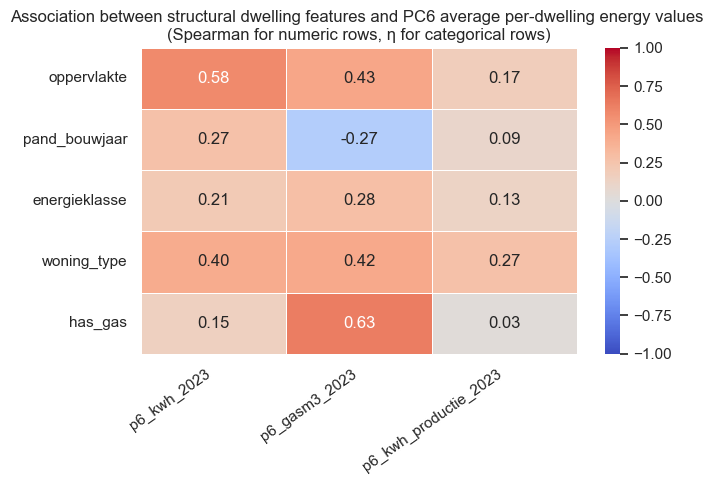

In [97]:
# ----------------------------
# 4.4G Structural ↔ energy association matrix
# ----------------------------

# energy variables
energy_vars = [
    "p6_kwh_2023",
    "p6_gasm3_2023",
    "p6_kwh_productie_2023"
]

# structural variables
struct_num = ["oppervlakte", "pand_bouwjaar"]
struct_cat = ["energieklasse", "woning_type", "has_gas"]

struct_vars = struct_num + struct_cat

# ensure energy columns numeric
for c in energy_vars:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# ensure has_gas numeric
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

# create association matrix
assoc_matrix = pd.DataFrame(index=struct_vars, columns=energy_vars)

for s in struct_vars:
    for e in energy_vars:

        # continuous ↔ continuous → Spearman
        if s in struct_num:
            assoc_matrix.loc[s, e] = df_dwelling[[s, e]].corr(method="spearman").iloc[0, 1]

        # categorical ↔ continuous → correlation ratio
        else:
            assoc_matrix.loc[s, e] = correlation_ratio(df_dwelling[s], df_dwelling[e])

assoc_matrix = assoc_matrix.astype(float)

display(assoc_matrix)

# ----------------------------
# Plot heatmap
# ----------------------------

plt.figure(figsize=(7,5))

ax = sns.heatmap(
    assoc_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

plt.title("Association between structural dwelling features and PC6 average per-dwelling energy values \n(Spearman for numeric rows, η for categorical rows)")

# fix x-axis readability
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=35,
    ha="right"
)

plt.tight_layout()
plt.show()

### Interpretation of structural–energy associations

The strongest relationship is observed between **floor area (`oppervlakte`) and electricity consumption (`p6_kwh_2023`)** (≈0.57), indicating that larger dwellings tend to consume substantially more electricity. This is consistent with expectations since larger homes typically contain more appliances, lighting, and conditioned space.

**Construction year (`pand_bouwjaar`)** exhibits a negative relationship with gas consumption (≈−0.28), suggesting that newer buildings tend to require less gas for heating due to improved insulation and building standards. **Dwelling type (`woning_type`)** shows moderate associations with both electricity and gas demand (≈0.30), indicating that building typology captures structural differences in dwelling scale.

In contrast, associations with **electricity production (`p6_kwh_productie_2023`)** are relatively weak across all structural variables, suggesting that photovoltaic adoption is influenced by additional factors beyond the building characteristics captured in this dataset.

Overall, the results indicate that residential energy demand is influenced by the **structural composition of the housing stock**, particularly dwelling size, typology, and heating infrastructure. This motivates the later modelling approach where PC6-level energy demand is related to the composition of dwelling characteristics within each postcode area.

### Methodological note

Energy variables are reported at **PC6 level**, meaning that all dwellings within the same postcode share identical energy values. As a result, postcode areas with more dwellings contribute more observations to the correlation analysis. The results should therefore be interpreted as **exploratory relationships between dwelling characteristics and area-level energy outcomes**, rather than strictly dwelling-level causal relationships.

## 5️⃣ PC6-level structural composition and energy analysis

The previous chapter examined structural dwelling characteristics at micro level and explored how these characteristics relate to postcode-level energy variables.

The next step is to move from the **dwelling level** to the **PC6 level**, since the final modelling stage is based on postcode areas rather than individual dwellings.

This requires constructing a new dataset with **one row per PC6**, where:

- dwelling-level structural information can be aggregated into postcode-level composition variables
- energy variables are expressed consistently at PC6 level

We proceed in structured steps:

1. Construct a clean **PC6 base dataset**
2. Examine **PC6 energy scaling**
3. Compute **PC6 structural composition variables**
4. Construct **size-normalized PC6 energy indicators**

### 5.1 Within-PC6 structural dispersion

Before aggregating dwelling-level variables to postcode level, it is useful to examine how heterogeneous dwellings are within each PC6 area. If dwellings inside a postcode area are structurally homogeneous, postcode averages provide a reliable representation of the housing stock. If large internal variation exists, aggregation may hide important structural differences.

To evaluate this, we measure the **coefficient of variation (CV)** of key dwelling characteristics within each PC6. The coefficient of variation is defined as:

$$ CV = \frac{{σ}}{{μ}} $$
where:
- σ is the standard deviation within a PC6
- μ is the mean value within the PC6

The CV measures **relative dispersion**, meaning the amount of variation compared to the typical level of the variable. For example:
- CV = 0.10 → variation equals about 10% of the mean
- CV = 0.25 → variation equals about 25% of the mean

This metric is useful because it allows dispersion to be compared across variables with different units and scales. The analysis focuses on two structural dwelling characteristics:
- `oppervlakte` — dwelling floor area  
- `pand_bouwjaar` — construction year

For each PC6 area we compute the coefficient of variation and examine the distribution of these values across postcode areas.

Number of PC6 areas: 257669

Summary statistics of within-PC6 dispersion (Coefficient of Variation):


,cv_oppervlakte,cv_bouwjaar
count,254398.000000,254398.000000
mean,0.173108,0.002509
std,0.143099,0.006443
min,0.000000,0.000000
1%,0.000000,0.000000
5%,0.000000,0.000000
25%,0.072926,0.000000
50%,0.142427,0.000000
75%,0.238276,0.001279
95%,0.436176,0.014895


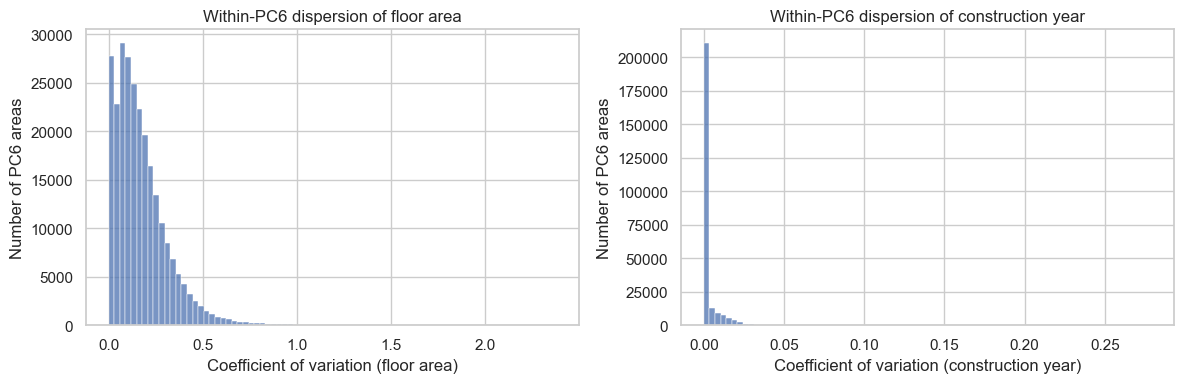

In [98]:
# ----------------------------
# 5.1 Within-PC6 structural dispersion (Coefficient of Variation)
# ----------------------------

# variables of interest
dispersion_vars = ["oppervlakte", "pand_bouwjaar"]

# compute mean and standard deviation within each PC6
pc6_mean = df_dwelling.groupby("postcode")[dispersion_vars].mean()
pc6_std = df_dwelling.groupby("postcode")[dispersion_vars].std()

# compute coefficient of variation
pc6_cv = pd.DataFrame({
    "cv_oppervlakte": pc6_std["oppervlakte"] / pc6_mean["oppervlakte"],
    "cv_bouwjaar": pc6_std["pand_bouwjaar"] / pc6_mean["pand_bouwjaar"]
})

print("Number of PC6 areas:", len(pc6_cv))

# summary statistics
print("\nSummary statistics of within-PC6 dispersion (Coefficient of Variation):")
display(
    pc6_cv.describe(percentiles=[0.01,0.05,0.25,0.5,0.75,0.95,0.99])
)

# ----------------------------
# visualization
# ----------------------------

fig, axes = plt.subplots(1,2, figsize=(12,4))

sns.histplot(pc6_cv["cv_oppervlakte"].dropna(), bins=80, ax=axes[0])
axes[0].set_title("Within-PC6 dispersion of floor area")
axes[0].set_xlabel("Coefficient of variation (floor area)")
axes[0].set_ylabel("Number of PC6 areas")

sns.histplot(pc6_cv["cv_bouwjaar"].dropna(), bins=80, ax=axes[1])
axes[1].set_title("Within-PC6 dispersion of construction year")
axes[1].set_xlabel("Coefficient of variation (construction year)")
axes[1].set_ylabel("Number of PC6 areas")

plt.tight_layout()
plt.show()

### Interpretation

The coefficient of variation shows that postcode areas exhibit **moderate internal variation in dwelling size but very little variation in construction year**.  
For floor area, the median CV is approximately **0.14**, meaning that the standard deviation of dwelling size within a typical PC6 area is about **14% of the mean dwelling size**. This indicates that most postcode areas contain dwellings of broadly similar size, although the upper tail of the distribution reveals some mixed neighbourhoods with substantially larger size variation.

In contrast, construction year shows **very low dispersion**. The median CV is **0**, indicating that more than half of postcode areas contain dwellings built in the same construction period. This reflects the common development pattern of Dutch neighbourhoods, where housing is often constructed as part of a single development phase.

Given the moderate within-PC6 variation in floor area and the very low within-PC6 variation in construction year, the use of `mean_oppervlakte` and `mean_bouwjaar` as PC6-level summary variables in the following aggregation step is considered appropriate.

### 5.2 Construct PC6 base dataset

We begin by creating a base dataset with **one observation per PC6**.

For each postcode area, we compute:

- `n_dwellings` — number of dwellings in the PC6
- `pc6_kwh_total_2023` — total electricity consumption in the PC6
- `pc6_gasm3_total_2023` — total gas consumption in the PC6
- `pc6_kwh_productie_total_2023` — total electricity production in the PC6


Electricity consumption and PV production are reported in the source dataset as average values per dwelling at a postcode-level. All three energy variables are aggregated consistently using `sum`, so that the resulting PC6 energy variables represent postcode-level totals.

In [99]:
# ----------------------------
# 5.2 Construct PC6 base dataset
# ----------------------------

# ensure energy variables are numeric
energy_cols = ["p6_kwh_2023", "p6_gasm3_2023", "p6_kwh_productie_2023"]

for c in energy_cols:
    df_dwelling[c] = pd.to_numeric(df_dwelling[c], errors="coerce")

# aggregate to PC6 level
pc6_base = (
    df_dwelling
    .groupby("postcode")
    .agg(
        gemeentecode=("gemeentecode", "first"),
        n_dwellings=("postcode", "size"),
        pc6_kwh_total_2023=("p6_kwh_2023", "sum"),
        pc6_gasm3_total_2023=("p6_gasm3_2023", "sum"),
        pc6_kwh_productie_total_2023=("p6_kwh_productie_2023", "sum")
    )
    .reset_index()
)

print("PC6 base dataset")
print("rows:", len(pc6_base))
print("unique PC6:", pc6_base["postcode"].nunique())

pc6_base.head()

PC6 base dataset
rows: 257669
unique PC6: 257669


,postcode,gemeentecode,n_dwellings,pc6_kwh_total_2023,pc6_gasm3_total_2023,pc6_kwh_productie_total_2023
0,1011AN,GM0363,26,68146.0,38114.0,0.0
1,1011AX,GM0363,16,51824.0,19799.0,0.0
2,1011BA,GM0363,9,17217.0,5202.0,387.0
3,1011BR,GM0363,12,22896.0,11664.0,0.0
4,1011CW,GM0363,13,37375.0,9997.0,2106.0


### 5.3 PC6 energy scaling diagnostics

Before choosing how to normalize energy consumption, we examine how total PC6 energy demand scales with the number of dwellings in each postcode area.

If energy increases proportionally with the number of dwellings, dividing energy by dwelling count would provide a meaningful measure of average demand per dwelling. If the relationship is non-linear, simple normalization may distort the structural signal.

To investigate this, we analyse the relationship between postcode size and three PC6 energy totals:

- `pc6_kwh_total_2023`
- `pc6_gasm3_total_2023`
- `pc6_kwh_productie_total_2023`

The scaling relationship is estimated using the regression model

$$
\log(E_{pc6}) = a + b \log(N_{pc6}) + \varepsilon
$$

where:

- $E_{pc6}$ is total PC6 energy demand
- $N_{pc6}$ is the number of dwellings in the postcode
- $a$ is the intercept
- $b$ is the scaling exponent
- $\varepsilon$ represents unexplained variation

The parameter of primary interest is the scaling exponent $b$.

- If $b = 1$, energy scales proportionally with postcode size
- If $b < 1$, larger postcode areas tend to consume less energy per dwelling on average
- If $b > 1$, larger postcode areas tend to consume more energy per dwelling

Log-log scatterplots and fitted scaling lines are used to visualize this relationship.

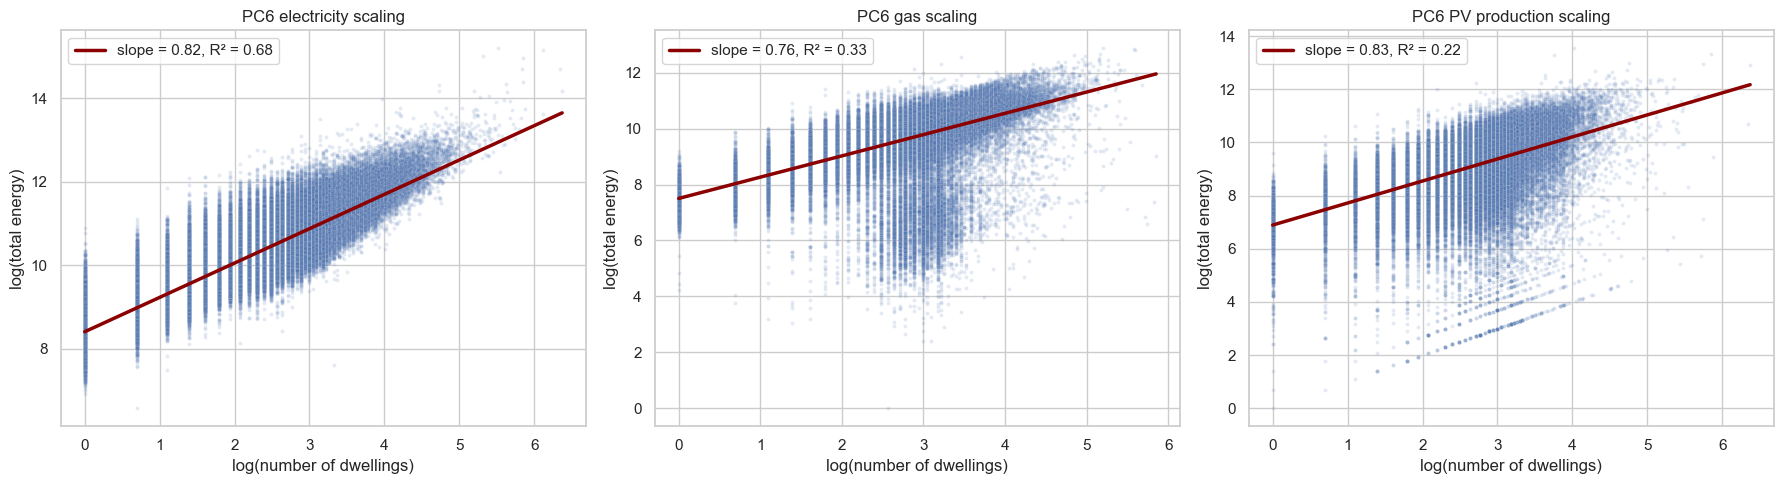


pc6_kwh_total_2023
log(E_pc6) = 8.401 + 0.823 * log(N_pc6)
scaling exponent b = 0.823
R² = 0.682

pc6_gasm3_total_2023
log(E_pc6) = 7.504 + 0.761 * log(N_pc6)
scaling exponent b = 0.761
R² = 0.332

pc6_kwh_productie_total_2023
log(E_pc6) = 6.891 + 0.828 * log(N_pc6)
scaling exponent b = 0.828
R² = 0.220


,Energy variable,Scaling exponent b,R²
0,Electricity consumption,0.823,0.682
1,Gas consumption,0.761,0.332
2,PV production,0.828,0.220


In [100]:
# ----------------------------
# 5.3 PC6 energy scaling diagnostics
# ----------------------------

from scipy.stats import linregress

scaling_vars = [
    "pc6_kwh_total_2023",
    "pc6_gasm3_total_2023",
    "pc6_kwh_productie_total_2023"
]

titles = [
    "PC6 electricity scaling",
    "PC6 gas scaling",
    "PC6 PV production scaling"
]

# dictionary to store regression results
scaling_results = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for var, title, ax in zip(scaling_vars, titles, axes):

    tmp = pc6_base.loc[
        (pc6_base["n_dwellings"] > 0) &
        (pc6_base[var] > 0)
    ].copy()

    tmp["log_n_dwellings"] = np.log(tmp["n_dwellings"])
    tmp["log_energy"] = np.log(tmp[var])

    sns.scatterplot(
        data=tmp,
        x="log_n_dwellings",
        y="log_energy",
        s=8,
        alpha=0.15,
        ax=ax
    )

    slope, intercept, r, p, se = linregress(
        tmp["log_n_dwellings"],
        tmp["log_energy"]
    )

    # store results
    scaling_results[var] = {
        "slope": slope,
        "intercept": intercept,
        "r2": r**2
    }

    # regression line
    x_line = np.linspace(
        tmp["log_n_dwellings"].min(),
        tmp["log_n_dwellings"].max(),
        200
    )
    y_line = intercept + slope * x_line

    ax.plot(
        x_line,
        y_line,
        color="darkred",
        linewidth=2.5,
        label=f"slope = {slope:.2f}, R² = {r**2:.2f}"
    )

    ax.set_title(title)
    ax.set_xlabel("log(number of dwellings)")
    ax.set_ylabel("log(total energy)")
    ax.legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Print stored scaling results
# ----------------------------

for var in scaling_vars:

    intercept = scaling_results[var]["intercept"]
    slope = scaling_results[var]["slope"]
    r2 = scaling_results[var]["r2"]

    print(f"\n{var}")
    print(f"log(E_pc6) = {intercept:.3f} + {slope:.3f} * log(N_pc6)")
    print(f"scaling exponent b = {slope:.3f}")
    print(f"R² = {r2:.3f}")

# ----------------------------
# Scaling results summary table
# ----------------------------

scaling_summary = pd.DataFrame({
    "Energy variable": [
        "Electricity consumption",
        "Gas consumption",
        "PV production"
    ],
    "Scaling exponent b": [
        scaling_results["pc6_kwh_total_2023"]["slope"],
        scaling_results["pc6_gasm3_total_2023"]["slope"],
        scaling_results["pc6_kwh_productie_total_2023"]["slope"]
    ],
    "R²": [
        scaling_results["pc6_kwh_total_2023"]["r2"],
        scaling_results["pc6_gasm3_total_2023"]["r2"],
        scaling_results["pc6_kwh_productie_total_2023"]["r2"]
    ]
})

scaling_summary["Scaling exponent b"] = scaling_summary["Scaling exponent b"].round(3)
scaling_summary["R²"] = scaling_summary["R²"].round(3)

display(scaling_summary)

### Interpretation of PC6 energy scaling

All estimated exponents are **below one**, indicating **sublinear scaling**. This means that energy demand increases with the number of dwellings but less than proportionally. For example, the electricity exponent of 0.823 implies that a 10% increase in the number of dwellings corresponds to approximately an **8.2% increase in electricity demand**.

The coefficient of determination ($R^2$) indicates how much of the variation in postcode energy demand is explained by postcode size alone. Electricity demand shows the strongest scaling relationship with postcode size, whereas gas consumption and PV production show weaker relationships, indicating that additional structural characteristics influence these energy outcomes.

The intercept $a$ represents the baseline energy level implied by the scaling relationship. Rewriting the model gives

$$
E_{pc6} = e^{a} \cdot N_{pc6}^{b}
$$

which shows that $e^{a}$ corresponds to the expected energy demand for a postcode containing a single dwelling. In practice, this intercept reflects the baseline energy intensity of the housing stock independent of postcode size.

Because the estimated exponents are below one, dividing energy by the number of dwellings would not fully remove the influence of postcode size. Postcode size should therefore be accounted for explicitly in the subsequent modelling stage.

### 5.4 Compute PC6 structural composition variables

We now compute structural composition indicators describing the housing stock within each postcode area.

These variables summarize the dwelling-level structural dataset at PC6 level.

Two types of indicators are constructed.

**Average structural characteristics**

- mean floor area (`mean_oppervlakte`)
- mean construction year (`mean_bouwjaar`)

**Composition shares**

- share of dwellings with gas connection (`share_has_gas`)
- share of each dwelling type (`woning_type`)
- share of each energy label (`energieklasse`)

These variables describe the structural composition of the housing stock within each postcode and will later be used to examine how building composition relates to energy demand.

A special case is the category `no_label`, which represents dwellings without a registered energy label. 
This category is retained as a separate share variable because it reflects **label coverage and structural characteristics of the housing stock**, rather than an energy-efficiency class.

In [101]:
# ----------------------------
# 5.4 Compute PC6 structural composition variables
# ----------------------------

df_dwelling["oppervlakte"] = pd.to_numeric(df_dwelling["oppervlakte"], errors="coerce")
df_dwelling["pand_bouwjaar"] = pd.to_numeric(df_dwelling["pand_bouwjaar"], errors="coerce")
df_dwelling["has_gas"] = df_dwelling["has_gas"].astype(int)

pc6_structure_basic = (
    df_dwelling
    .groupby("postcode")
    .agg(
        mean_oppervlakte=("oppervlakte", "mean"),
        mean_bouwjaar=("pand_bouwjaar", "mean"),
        share_has_gas=("has_gas", "mean")
    )
    .reset_index()
)

pc6_woningtype = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["woning_type"],
    normalize="index"
)

pc6_woningtype.columns = [
    f"share_woning_type_{c}" for c in pc6_woningtype.columns
]
pc6_woningtype = pc6_woningtype.reset_index()

pc6_energylabel = pd.crosstab(
    df_dwelling["postcode"],
    df_dwelling["energieklasse"],
    normalize="index"
)

# enforce consistent energy label column order
present_labels = [c for c in label_order if c in pc6_energylabel.columns]
pc6_energylabel = pc6_energylabel.reindex(columns=present_labels)

pc6_energylabel.columns = [
    f"share_energieklasse_{c}" for c in pc6_energylabel.columns
]
pc6_energylabel = pc6_energylabel.reset_index()

pc6_dataset = (
    pc6_base
    .merge(pc6_structure_basic, on="postcode", how="left")
    .merge(pc6_woningtype, on="postcode", how="left")
    .merge(pc6_energylabel, on="postcode", how="left")
)

# clarify that this variable represents label coverage, not an efficiency class
pc6_dataset = pc6_dataset.rename(columns={
    "share_energieklasse_no_label": "share_no_energy_label"
})

# replace missing composition shares with zero
pc6_dataset = pc6_dataset.fillna(0)

print("PC6 structural composition dataset")
print("rows:", len(pc6_dataset))
print("columns:", len(pc6_dataset.columns))

pc6_dataset.head()

PC6 structural composition dataset
rows: 257669
columns: 31


,postcode,gemeentecode,n_dwellings,pc6_kwh_total_2023,pc6_gasm3_total_2023,pc6_kwh_productie_total_2023,mean_oppervlakte,mean_bouwjaar,share_has_gas,share_woning_type_Appartement,...,share_energieklasse_A++,share_energieklasse_A+,share_energieklasse_A,share_energieklasse_B,share_energieklasse_C,share_energieklasse_D,share_energieklasse_E,share_energieklasse_F,share_energieklasse_G,share_no_energy_label
0,1011AN,GM0363,26,68146.0,38114.0,0.0,75.615385,1789.923077,0.730769,0.526316,...,0.0,0.0,0.346154,0.038462,0.076923,0.076923,0.153846,0.0000,0.038462,0.269231
1,1011AX,GM0363,16,51824.0,19799.0,0.0,113.312500,1688.812500,0.812500,0.000000,...,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625,0.000000,0.937500
2,1011BA,GM0363,9,17217.0,5202.0,387.0,58.111111,1975.555556,0.666667,0.250000,...,0.0,0.0,0.444444,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.555556
3,1011BR,GM0363,12,22896.0,11664.0,0.0,85.333333,1818.750000,0.750000,1.000000,...,0.0,0.0,0.000000,0.000000,0.166667,0.000000,0.166667,0.0000,0.000000,0.666667
4,1011CW,GM0363,13,37375.0,9997.0,2106.0,83.384615,1673.769231,1.000000,0.142857,...,0.0,0.0,0.000000,0.000000,0.076923,0.000000,0.461538,0.0000,0.000000,0.461538


### 5.5 Size-normalized PC6 energy indicators

The scaling diagnostics in Section 5.4 showed that total PC6 energy demand increases sublinearly with the number of dwellings. To remove the mechanical influence of postcode size, we compute **size-normalized energy indicators**:

$$
E_{\text{normalized}} = \frac{E_{pc6}}{N_{pc6}^{b}}
$$

where:

- $E_{pc6}$ is total energy consumption in the postcode area  
- $N_{pc6}$ is the number of dwellings  
- $b$ is the scaling exponent from Section 5.4  

This transformation preserves variation associated with structural housing composition while removing size bias.

Normalized energy variables:

- `kwh_norm_pc6`
- `gas_norm_pc6`
- `pv_norm_pc6`

In [102]:
# ----------------------------
# 5.5 Size-normalized PC6 energy indicators
# ----------------------------

b_kwh = scaling_results["pc6_kwh_total_2023"]["slope"]
b_gas = scaling_results["pc6_gasm3_total_2023"]["slope"]
b_pv  = scaling_results["pc6_kwh_productie_total_2023"]["slope"]

pc6_dataset["kwh_norm_pc6"] = pc6_dataset["pc6_kwh_total_2023"] / (pc6_dataset["n_dwellings"] ** b_kwh)
pc6_dataset["gas_norm_pc6"] = pc6_dataset["pc6_gasm3_total_2023"] / (pc6_dataset["n_dwellings"] ** b_gas)
pc6_dataset["pv_norm_pc6"] = pc6_dataset["pc6_kwh_productie_total_2023"] / (pc6_dataset["n_dwellings"] ** b_pv)

pc6_dataset[["n_dwellings", "kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]].describe()

,n_dwellings,kwh_norm_pc6,gas_norm_pc6,pv_norm_pc6
count,257669.000000,257669.000000,257669.000000,257669.000000
mean,18.565377,4830.748453,1935.637685,444.886678
std,12.778306,2325.774251,1061.739696,899.483865
min,1.000000,129.850380,0.000000,0.000000
25%,12.000000,3498.090174,1481.315049,0.000000
50%,17.000000,4363.416140,1939.771872,0.000000
75%,23.000000,5476.810083,2418.304748,516.865674
max,586.000000,56799.319848,23251.388394,26897.124544


### 5.6 Association between PC6 composition and normalized energy

After removing the mechanical effect of postcode size, we investigate how **structural housing composition** relates to energy intensity across postcode areas.

Structural variables:

- `mean_oppervlakte` — mean floor area  
- `mean_bouwjaar` — mean construction year  
- `share_has_gas` — fraction of gas-connected dwellings  
- Dwelling type shares  
- Energy label shares  

Normalized energy indicators:

- `kwh_norm_pc6`  
- `gas_norm_pc6`  
- `pv_norm_pc6`  

Spearman correlation is used because:

- Variables are skewed  
- Relationships may be monotonic rather than linear  
- Shares are bounded between 0 and 1

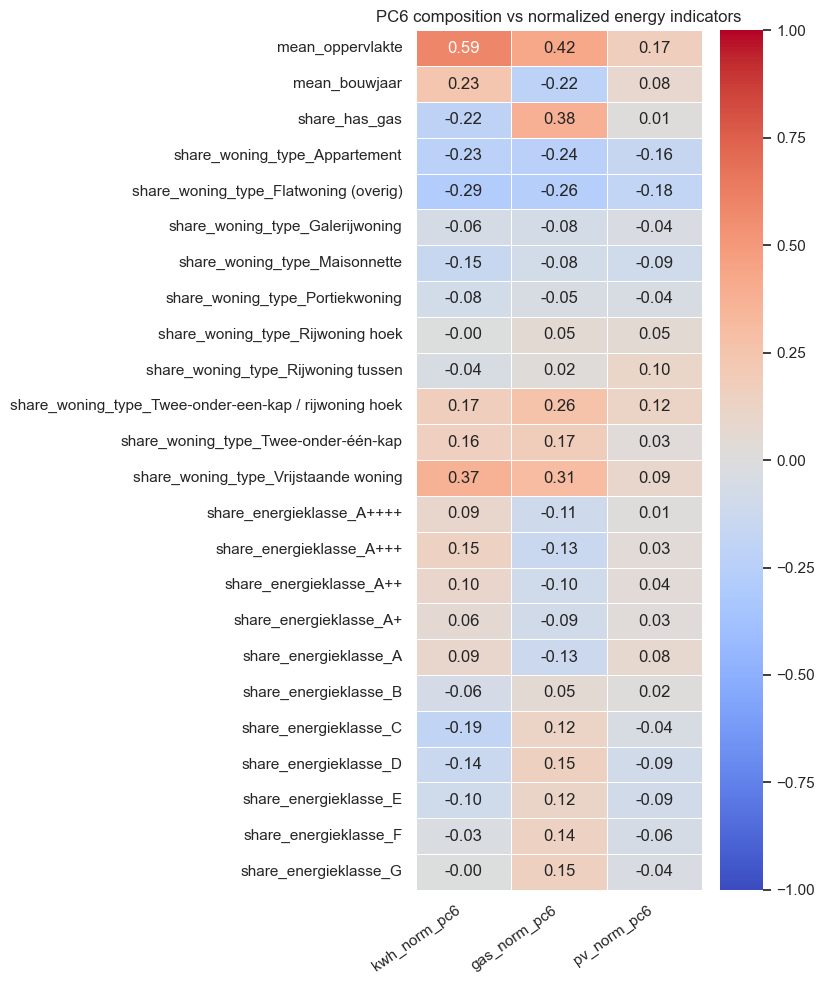

In [103]:
# ----------------------------
# 5.6 PC6 composition vs normalized energy
# ----------------------------

energy_norm_vars = [
    "kwh_norm_pc6",
    "gas_norm_pc6",
    "pv_norm_pc6"
]

composition_vars = [
    "mean_oppervlakte",
    "mean_bouwjaar",
    "share_has_gas"
]

composition_vars += [
    c for c in pc6_dataset.columns if c.startswith("share_woning_type_")
]

composition_vars += [
    c for c in pc6_dataset.columns if c.startswith("share_energieklasse_")
]

corr_block = (
    pc6_dataset[composition_vars + energy_norm_vars]
    .corr(method="spearman")
    .loc[composition_vars, energy_norm_vars]
)

plt.figure(figsize=(8,10))
ax = sns.heatmap(
    corr_block,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5
)

ax.set_xticklabels(
    energy_norm_vars,
    rotation=35,
    ha="right"
)

plt.title("PC6 composition vs normalized energy indicators")
plt.tight_layout()
plt.show()

### Diagnostic 1: correlation between postcode size and normalized energy

To verify that normalization removed the mechanical influence of postcode size, we examine correlations between the number of dwellings and the normalized energy indicators.

If normalization is successful, these correlations should be close to zero.

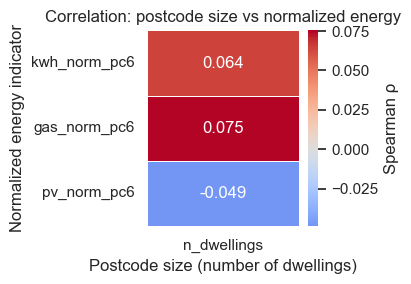

In [104]:
# ----------------------------
# Diagnostic heatmap: normalized energy vs postcode size
# ----------------------------

norm_vars = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]
size_var = "n_dwellings"

# compute Spearman correlation between size and normalized energy
size_corrs = [pc6_dataset[[size_var, var]].corr(method="spearman").iloc[0,1] for var in norm_vars]

# DataFrame for heatmap
heatmap_df = pd.DataFrame(size_corrs, index=norm_vars, columns=[size_var])

plt.figure(figsize=(4,3))
sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    cbar_kws={"label": "Spearman ρ"},
    linewidths=0.5
)
plt.title("Correlation: postcode size vs normalized energy")
plt.ylabel("Normalized energy indicator")
plt.xlabel("Postcode size (number of dwellings)")
plt.tight_layout()
plt.show()

### Diagnostic 2: regression test

A log-log regression of normalized energy against postcode size checks whether any residual scaling remains after normalization.
Slope values near zero and $R^2 \approx 0$ indicate that variation in normalized energy is no longer explained by the number of dwellings.

In [105]:
# ----------------------------
# Diagnostic 2 — Check remaining log-log dependence
# ----------------------------

norm_vars = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]

for var in norm_vars:

    tmp = pc6_dataset.loc[
        (pc6_dataset["n_dwellings"] > 0) &
        (pc6_dataset[var] > 0)
    ].copy()

    log_n = np.log(tmp["n_dwellings"])
    log_e = np.log(tmp[var])

    slope, intercept, r, p, se = linregress(log_n, log_e)

    print(f"\n{var}")
    print("log-log slope (should be ≈ 0):", round(slope, 4))
    print("R²:", round(r**2, 4))


kwh_norm_pc6
log-log slope (should be ≈ 0): 0.0
R²: 0.0

gas_norm_pc6
log-log slope (should be ≈ 0): -0.0
R²: 0.0

pv_norm_pc6
log-log slope (should be ≈ 0): -0.0
R²: 0.0


### Diagnostic 3 – comparison: normalized vs reported PC6 energy

To visualise the effect of size-normalization, we compute Spearman correlations between **PC6 composition variables** and:

1. **Normalized energy indicators** (`kwh_norm_pc6`, `gas_norm_pc6`, `pv_norm_pc6`)  
2. **Reported total energy** (`pc6_kwh_total_2023`, `pc6_gasm3_total_2023`, `pc6_kwh_productie_total_2023`)

The resulting correlation matrices are displayed side by side for comparison. This allows us to see how normalization clarifies the structural signal in the data.

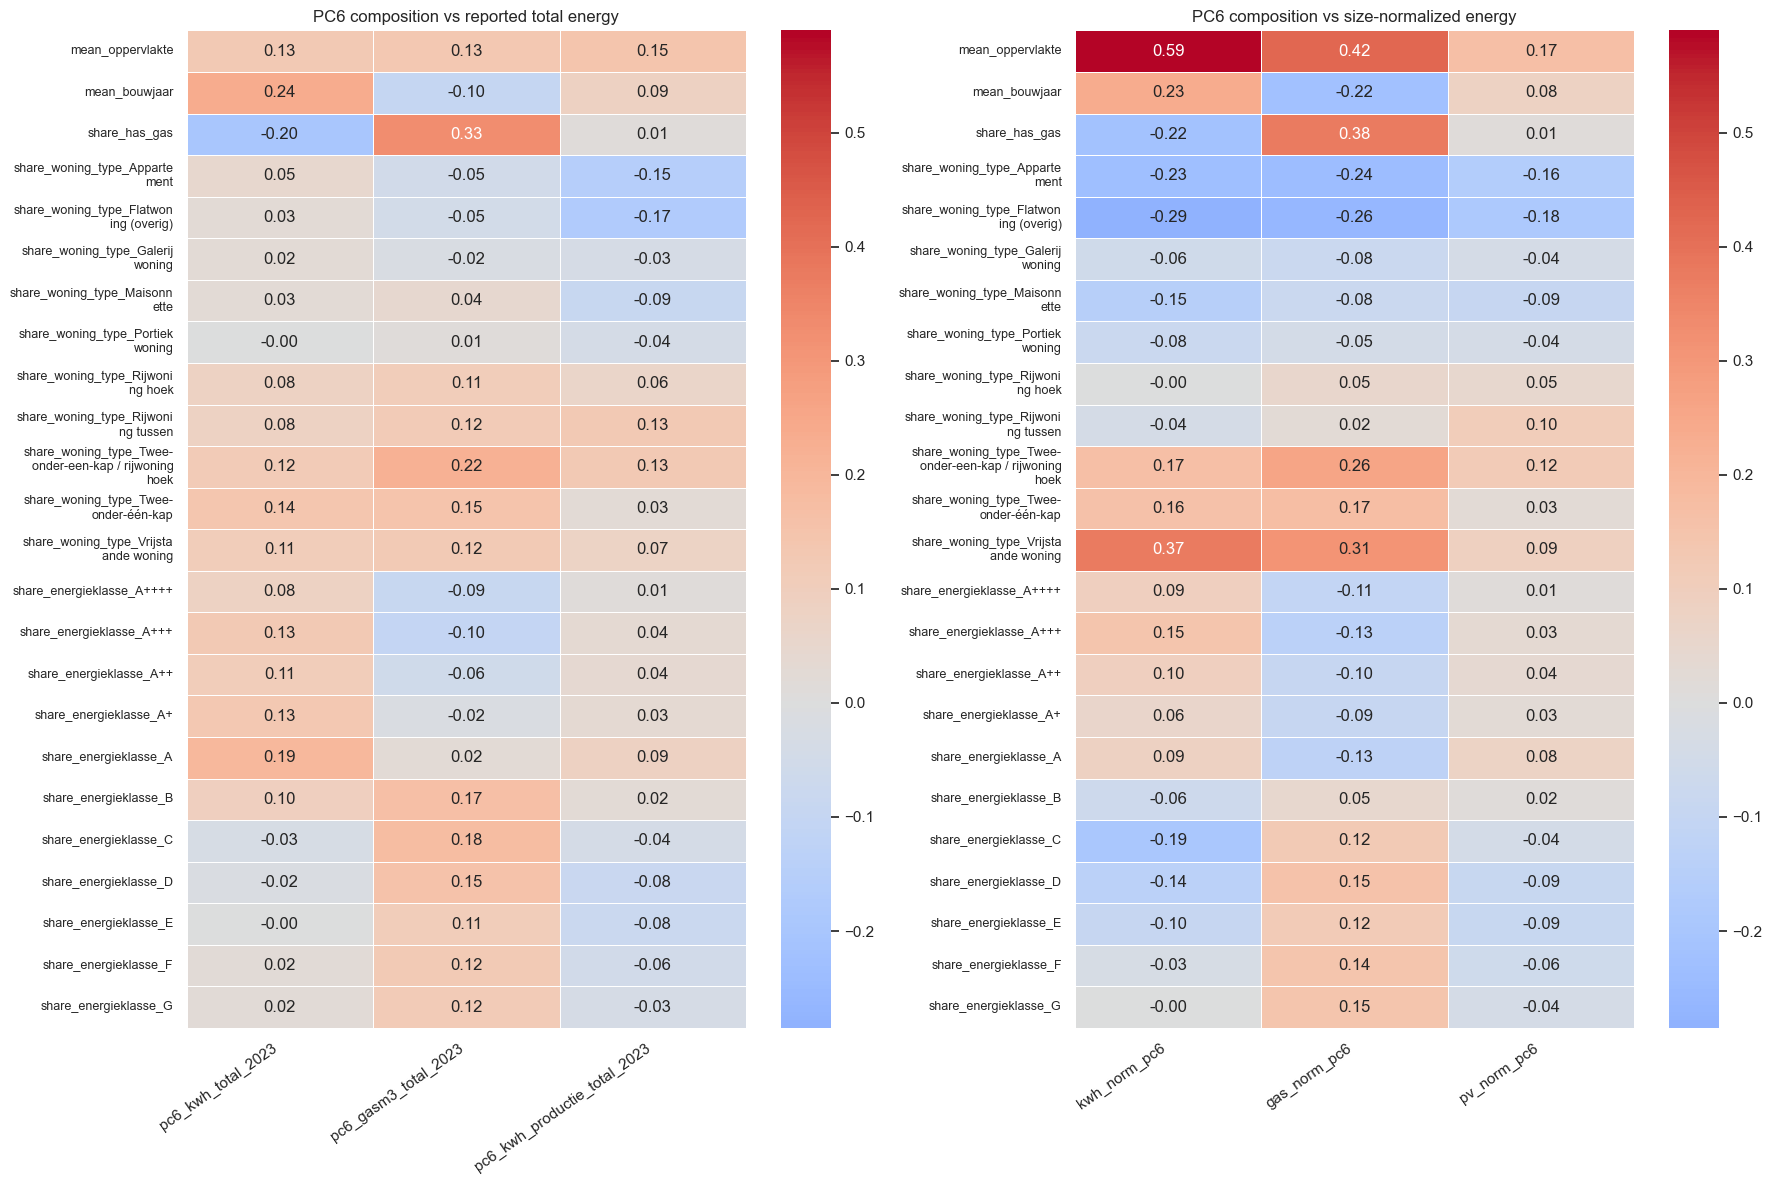

In [106]:
# ----------------------------
# Diagnostic 3: side-by-side correlation comparison (shared color scale)
# ----------------------------

from textwrap import fill

# Energy variables
energy_reported = ["pc6_kwh_total_2023", "pc6_gasm3_total_2023", "pc6_kwh_productie_total_2023"]
energy_normalized = ["kwh_norm_pc6", "gas_norm_pc6", "pv_norm_pc6"]

# Composition variables
composition_vars = [
    "mean_oppervlakte",
    "mean_bouwjaar",
    "share_has_gas"
]
composition_vars += [c for c in pc6_dataset.columns if c.startswith("share_woning_type_")]
composition_vars += [c for c in pc6_dataset.columns if c.startswith("share_energieklasse_")]

# Compute correlation blocks
corr_reported = pc6_dataset[composition_vars + energy_reported].corr(method="spearman").loc[composition_vars, energy_reported]
corr_normalized = pc6_dataset[composition_vars + energy_normalized].corr(method="spearman").loc[composition_vars, energy_normalized]

# Shared color scale across both heatmaps
shared_min = min(corr_reported.min().min(), corr_normalized.min().min())
shared_max = max(corr_reported.max().max(), corr_normalized.max().max())

# Wrap long y-axis labels
wrapped_labels = [fill(label, width=25) for label in composition_vars]

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(18, 12))

sns.heatmap(
    corr_reported,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=shared_min,
    vmax=shared_max,
    linewidths=0.5,
    ax=axes[0]
)
axes[0].set_title("PC6 composition vs reported total energy")
axes[0].set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=35, ha="right")

sns.heatmap(
    corr_normalized,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=shared_min,
    vmax=shared_max,
    linewidths=0.5,
    ax=axes[1]
)
axes[1].set_title("PC6 composition vs size-normalized energy")
axes[1].set_yticklabels(wrapped_labels, rotation=0, fontsize=9)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=35, ha="right")

plt.tight_layout()
plt.show()

### Interpretation of PC6 energy diagnostics

**Diagnostic 1 – correlation with postcode size:**  
The heatmap shows that after normalization, the correlation between number of dwellings (`n_dwellings`) and normalized energy indicators is close to zero (ρ ≈ 0.07 for electricity, 0.08 for gas, −0.05 for PV), confirming that the mechanical effect of postcode size has been largely removed.

**Diagnostic 2 – regression of normalized energy vs postcode size:**  
The regression slopes are near zero and R² values are extremely small, indicating that postcode size no longer explains variation in normalized energy. This supports the effectiveness of the normalization procedure.

**Diagnostic 3 – composition vs energy correlation matrices:**  
Comparing normalized vs reported total energy shows that normalization amplifies the structural signal of housing composition. For example, `mean_oppervlakte` shows a stronger positive correlation with normalized electricity than with raw totals. This demonstrates that removing the postcode size effect makes structural differences more clearly visible.

Overall, these diagnostics confirm that **size-normalized energy indicators are suitable for analysing how PC6 composition influences energy demand**, without the confounding effect of postcode size.

*Note:* "Reported total energy" refers to the PC6-level totals of electricity and gas (sum across all dwellings) and PV production, before any normalization.

## 6️⃣ PC6-level regression analysis

The previous sections examined how structural housing characteristics vary across postcode areas and how these characteristics relate descriptively to normalized electricity demand. These earlier analyses provided useful evidence on bivariate relationships and spatial variation, but they did not account for the joint influence of multiple housing characteristics simultaneously.

The purpose of this chapter is to estimate statistical models that relate postcode-level normalized electricity demand to the structural composition of the housing stock. Two objectives are pursued.

First, regression models are used to quantify how average dwelling size, construction year, gas availability, dwelling type composition, and energy label composition are associated with normalized electricity demand across postcode areas.

Second, the predictive performance of the preferred regression specification is evaluated out of sample and compared with a nonlinear machine-learning benchmark. This makes it possible to assess both the interpretability of the regression framework and the potential predictive gains from a more flexible nonlinear method.

The analysis proceeds in six steps.

1. define the regression dataset and model variables  
2. assess multicollinearity among predictors  
3. estimate alternative regression specifications  
4. compare model fit and residual behaviour to select a preferred model  
5. evaluate inference robustness for the preferred model  
6. assess out-of-sample prediction and compare the preferred regression model with a nonlinear benchmark

This structure is designed to keep the chapter analytically coherent. Model specification and model selection are addressed first. Diagnostics related to statistical inference are then applied to the preferred model only. Finally, predictive performance is evaluated in a separate step using cross-validation.

### 6.1 Regression dataset and model specification

The regression analysis uses the PC6 dataset constructed in Chapter 5, where each observation corresponds to one postcode area. The dataset combines postcode-level structural indicators of the housing stock with normalized electricity demand.

The dependent variable is:

- $kwh_{norm,pc6}$: normalized electricity consumption in postcode area $pc6$

This variable was constructed in Chapter 5 to reduce the mechanical influence of postcode size and to focus the analysis on structural differences in the housing stock rather than on the number of dwellings alone.

The explanatory variables are grouped into three categories.

**Structural averages**

- `mean_oppervlakte`: mean dwelling floor area within the postcode area  
- `mean_bouwjaar`: mean construction year within the postcode area  

These variables summarize average physical characteristics of the local housing stock.

**Infrastructure indicator**

- `share_has_gas`: share of dwellings in the postcode area with a gas connection  

This variable captures the extent to which the local housing stock relies on gas infrastructure. Since gas and electricity can substitute for some household energy services, variation in gas availability may be associated with differences in electricity demand.

**Composition shares**

- `share_woning_type_*`: postcode-level shares of dwelling types  
- `share_energieklasse_*`: postcode-level shares of energy label categories  

These variables describe the structural composition of the housing stock. Two postcode areas may have similar average floor area, for example, but still differ substantially in their dwelling type mix or energy label distribution.

Because the dwelling-type shares sum to one within each postcode area, and the energy-label shares also sum to one, one category from each group must be omitted to avoid perfect multicollinearity. These omitted categories act as reference categories for interpretation.

In this analysis, the following reference categories are used:

- Dwelling type reference: `share_woning_type_appartement`  
- Energy label reference: `share_energieklasse_G`

All estimated coefficients for included dwelling-type shares are therefore interpreted relative to the apartment category, and all estimated coefficients for included energy-label shares are interpreted relative to energy label G.

For example, a positive coefficient on a dwelling-type share indicates that postcode areas with a higher share of that dwelling type tend to exhibit higher normalized electricity demand relative to postcode areas with a higher share of apartments, holding other factors constant.

The baseline regression model is specified as:

$$
kwh_{norm,pc6} =
\beta_0
+ \beta_1 mean\_oppervlakte_{pc6}
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6}
+ \sum_j \beta_{4j} share\_woning\_type_{j,pc6}
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6}
+ \varepsilon_{pc6}
$$

where:

- $\beta_0$ is the intercept  
- $\beta_1, \beta_2, \beta_3$ are coefficients for the average structural variables and gas-connection share  
- $share\_woning\_type_{j,pc6}$ denotes the share of dwelling type $j$ in postcode area $pc6$, excluding the apartment reference category  
- $share\_energieklasse_{k,pc6}$ denotes the share of energy label category $k$ in postcode area $pc6$, excluding the label G reference category  
- $j$ indexes the included dwelling-type categories  
- $k$ indexes the included energy-label categories  
- $\varepsilon_{pc6}$ is the regression error term, representing variation in normalized electricity demand not explained by the observed structural variables

This specification assumes that normalized electricity demand can be described as an additive function of average structural characteristics and compositional shares. It provides the starting point for the alternative regression specifications examined in the next sections.

In [107]:
# 6.1 Construct regression dataset

# dependent variable
y = pc6_dataset["kwh_norm_pc6"]

# identify composition variables
woningtype_cols_full = [
    c for c in pc6_dataset.columns
    if c.startswith("share_woning_type_")
]

label_cols_full = [
    c for c in pc6_dataset.columns
    if c.startswith("share_energieklasse_")
]

# explicit reference categories
ref_woningtype = "share_woning_type_appartement"   # adjust if needed
ref_label = "share_energieklasse_G"                # adjust if needed

woningtype_cols = [
    c for c in woningtype_cols_full
    if c != ref_woningtype
]

label_cols = [
    c for c in label_cols_full
    if c != ref_label
]

print("Reference dwelling type:", ref_woningtype)
print("Reference energy label:", ref_label)

# predictor matrix
X = pc6_dataset[
    ["mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
].copy()

# add intercept
X = sm.add_constant(X)

print("Regression matrix shape:")
print("Observations:", X.shape[0])
print("Predictors:", X.shape[1])

display(X.head())

Reference dwelling type: share_woning_type_appartement
Reference energy label: share_energieklasse_G
Regression matrix shape:
Observations: 257669
Predictors: 24


,const,mean_oppervlakte,mean_bouwjaar,share_has_gas,share_woning_type_Appartement,share_woning_type_Flatwoning (overig),share_woning_type_Galerijwoning,share_woning_type_Maisonnette,share_woning_type_Portiekwoning,share_woning_type_Rijwoning hoek,...,share_energieklasse_A++++,share_energieklasse_A+++,share_energieklasse_A++,share_energieklasse_A+,share_energieklasse_A,share_energieklasse_B,share_energieklasse_C,share_energieklasse_D,share_energieklasse_E,share_energieklasse_F
0,1.0,75.615385,1789.923077,0.730769,0.526316,0.421053,0.0,0.052632,0.0,0.0,...,0.0,0.0,0.0,0.0,0.346154,0.038462,0.076923,0.076923,0.153846,0.0000
1,1.0,113.312500,1688.812500,0.812500,0.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0625
2,1.0,58.111111,1975.555556,0.666667,0.250000,0.500000,0.0,0.250000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.444444,0.000000,0.000000,0.000000,0.000000,0.0000
3,1.0,85.333333,1818.750000,0.750000,1.000000,0.000000,0.0,0.000000,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.166667,0.000000,0.166667,0.0000
4,1.0,83.384615,1673.769231,1.000000,0.142857,0.714286,0.0,0.142857,0.0,0.0,...,0.0,0.0,0.0,0.0,0.000000,0.000000,0.076923,0.000000,0.461538,0.0000


### 6.2 Multicollinearity assessment

Before estimating the regression models, it is necessary to assess whether the explanatory variables are strongly collinear. Multicollinearity does not bias the fitted values of an Ordinary Least Squares model, but it can inflate the variance of the estimated coefficients and make coefficient interpretation unstable.

This issue is particularly relevant here because the model includes postcode-level compositional shares. Since dwelling-type shares and energy-label shares are derived from the same local housing stock, some degree of correlation between these variables is expected.

To evaluate the severity of this issue, Variance Inflation Factors (VIF) are computed for the predictors. The VIF for predictor $x_j$ is defined as:

$$
VIF_j = \frac{1}{1 - R_j^2}
$$

where:

- $R_j^2$ is the coefficient of determination obtained when predictor $x_j$ is regressed on all remaining predictors

The VIF therefore measures how much the variance of the estimated coefficient on variable $j$ is inflated due to linear dependence with the other explanatory variables.

As a rule of thumb:

- VIF < 5 indicates limited multicollinearity  
- 5 ≤ VIF < 10 indicates moderate multicollinearity  
- VIF ≥ 10 indicates potentially problematic multicollinearity

The objective of this diagnostic is not to eliminate all overlap among predictors, since some overlap is structurally unavoidable in compositional housing data. Rather, the purpose is to assess whether multicollinearity becomes strong enough to undermine the interpretability of the regression coefficients.

In [108]:
# 6.2 VIF diagnostics

from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = X.drop(columns="const").copy()

vif = pd.DataFrame()
vif["variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif = vif.sort_values("VIF", ascending=False).reset_index(drop=True)
display(vif)

,variable,VIF
0,mean_bouwjaar,68.387591
1,mean_oppervlakte,14.469426
2,share_has_gas,13.455629
3,share_woning_type_Rijwoning tussen,10.920141
4,share_woning_type_Twee-onder-een-kap / rijwoni...,6.477958
5,share_woning_type_Flatwoning (overig),5.962365
6,share_woning_type_Vrijstaande woning,5.353794
7,share_woning_type_Appartement,3.569494
8,share_energieklasse_C,2.512455
9,share_energieklasse_A,2.344235


### 6.3 Alternative regression specifications

The substantive objective of the regression analysis is to estimate how structural housing characteristics relate to normalized electricity demand. However, the exact functional form of this relationship is not known a priori. For that reason, three alternative Ordinary Least Squares specifications are estimated and compared.

The purpose of this step is to determine which functional form provides the most appropriate representation of postcode-level electricity demand while preserving interpretability.

The three specifications are:

1. a linear model in levels  
2. a log-level model with the dependent variable transformed logarithmically  
3. a log-log model in which both the dependent variable and average floor area are expressed in logarithmic form

These models differ in how they represent the scale of electricity demand and the effect of dwelling size. Estimating them side by side makes it possible to assess whether transformations improve model fit, reduce residual skewness, and provide a more empirically adequate specification.

#### 6.3.1 Linear OLS specification

The first model is estimated in levels using Ordinary Least Squares. This serves as the baseline specification.

The model is:

$$
kwh_{norm,pc6} =
\beta_0
+ \beta_1 mean\_oppervlakte_{pc6}
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6}
+ \sum_j \beta_{4j} share\_woning\_type_{j,pc6}
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6}
+ \varepsilon_{pc6}
$$

In this form, each coefficient represents the change in normalized electricity demand associated with a one-unit increase in the corresponding explanatory variable, holding the remaining variables constant.

This model is attractive because of its straightforward interpretation. At the same time, if the dependent variable is strongly right-skewed, estimation in levels may place disproportionate weight on observations with unusually high electricity demand. For that reason, the linear specification is treated as a baseline against which transformed alternatives can be compared.

In [109]:
# 6.3.1 Linear OLS model

model_linear = sm.OLS(y, X).fit()

print(model_linear.summary())

                            OLS Regression Results                            
Dep. Variable:           kwh_norm_pc6   R-squared:                       0.305
Model:                            OLS   Adj. R-squared:                  0.305
Method:                 Least Squares   F-statistic:                     4916.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:48:56   Log-Likelihood:            -2.3161e+06
No. Observations:              257669   AIC:                         4.632e+06
Df Residuals:                  257645   BIC:                         4.633e+06
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

#### 6.3.2 Log-level OLS specification

The dependent variable $kwh_{norm,pc6}$ is right-skewed, meaning that a relatively small number of postcode areas exhibit substantially higher normalized electricity demand than the majority of observations. When this occurs, estimation in levels may lead to a residual structure that is difficult to model well with a linear specification.

To address this issue, an alternative model is estimated in which the dependent variable is transformed using the natural logarithm:

$$
\log(kwh_{norm,pc6}) =
\beta_0
+ \beta_1 mean\_oppervlakte_{pc6}
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6}
+ \sum_j \beta_{4j} share\_woning\_type_{j,pc6}
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6}
+ \varepsilon_{pc6}
$$

where:

- $\log(kwh_{norm,pc6})$ is the natural logarithm of normalized electricity demand  
- the remaining terms are defined as in the baseline model

This specification preserves the additive structure in the explanatory variables, but models variation in electricity demand on a logarithmic scale. As a result, the model places greater emphasis on proportional differences rather than absolute differences.

Because the logarithm is defined only for strictly positive values, the estimation sample is restricted to postcode areas with:

$$
kwh_{norm,pc6} > 0
$$

This specification is estimated to assess whether log-transforming the dependent variable improves fit and residual behaviour relative to the linear model.

In [110]:
# 6.3.2 Log-level OLS model

# keep only postcode areas with positive normalized electricity demand
reg_data_log = pc6_dataset.loc[pc6_dataset["kwh_norm_pc6"] > 0].copy()

# create log dependent variable
reg_data_log["log_kwh_norm_pc6"] = np.log(reg_data_log["kwh_norm_pc6"])

# dependent variable
y_log = reg_data_log["log_kwh_norm_pc6"]

# predictors on positive-only sample
X_log = reg_data_log[
    ["mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
].copy()

X_log = sm.add_constant(X_log)

print("Log-model dataset shape:")
print("Observations:", X_log.shape[0])
print("Predictors:", X_log.shape[1])

model_log = sm.OLS(y_log, X_log).fit()

print(model_log.summary())

Log-model dataset shape:
Observations: 257669
Predictors: 24
                            OLS Regression Results                            
Dep. Variable:       log_kwh_norm_pc6   R-squared:                       0.371
Model:                            OLS   Adj. R-squared:                  0.371
Method:                 Least Squares   F-statistic:                     6617.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:48:57   Log-Likelihood:                -60161.
No. Observations:              257669   AIC:                         1.204e+05
Df Residuals:                  257645   BIC:                         1.206e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

Inspection of the residual behaviour of the log-level specification is also useful for guiding further model development. If systematic structure remains after log-transforming the dependent variable, this may indicate that one or more explanatory variables still enter the model in an empirically restrictive functional form.

#### 6.3.3 Log-log OLS specification with logarithmic floor area

Average dwelling floor area is one of the most important structural characteristics in the model. A linear effect of floor area implies that a 10 m² increase has the same marginal association with electricity demand regardless of whether the initial dwelling size is small or large.

This assumption may be too restrictive. In practice, the relationship between dwelling size and electricity demand may be proportional rather than linear. For example, the effect of increasing floor area from 50 m² to 60 m² may differ from the effect of increasing it from 150 m² to 160 m².

Building on the previous specification, a third model is therefore estimated in which both normalized electricity demand and average floor area are expressed in logarithmic form:

$$
\log(kwh_{norm,pc6}) =
\beta_0
+ \beta_1 \log(mean\_oppervlakte_{pc6})
+ \beta_2 mean\_bouwjaar_{pc6}
+ \beta_3 share\_has\_gas_{pc6}
+ \sum_j \beta_{4j} share\_woning\_type_{j,pc6}
+ \sum_k \beta_{5k} share\_energieklasse_{k,pc6}
+ \varepsilon_{pc6}
$$

where:

- $\log(mean\_oppervlakte_{pc6})$ is the natural logarithm of average dwelling floor area  
- the remaining variables are defined as before

In this model, the coefficient on $\log(mean\_oppervlakte)$ is interpreted as an elasticity:

$$
\beta_1 = \frac{\partial \log(kwh_{norm,pc6})}{\partial \log(mean\_oppervlakte_{pc6})}
$$

This means that $\beta_1$ measures the approximate percentage change in normalized electricity demand associated with a 1% increase in average dwelling floor area, holding the remaining explanatory variables constant.

This specification is estimated to assess whether the size-demand relationship is better captured in proportional terms.

In [111]:
# 6.3.3 Log-log OLS model with log floor area

reg_data_log = reg_data_log.copy()

# create log-transformed floor area
reg_data_log["log_mean_oppervlakte"] = np.log(reg_data_log["mean_oppervlakte"])

# predictors
X_log_area = reg_data_log[
    ["log_mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
].copy()

X_log_area = sm.add_constant(X_log_area)

# dependent variable
y_log_area = reg_data_log["log_kwh_norm_pc6"]

# estimate model
model_log_area = sm.OLS(y_log_area, X_log_area).fit()

print(model_log_area.summary())

                            OLS Regression Results                            
Dep. Variable:       log_kwh_norm_pc6   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     7099.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:48:57   Log-Likelihood:                -56718.
No. Observations:              257669   AIC:                         1.135e+05
Df Residuals:                  257645   BIC:                         1.137e+05
Df Model:                          23                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

### 6.4 Comparison and selection of the preferred regression specification

The three candidate specifications are compared to determine which functional form provides the most appropriate representation of postcode-level electricity demand.

The comparison is based on three criteria.

**1. Model fit**

Model fit is assessed using:

- Adjusted $R^2$
- Akaike Information Criterion (AIC)
- Bayesian Information Criterion (BIC)

Adjusted $R^2$ evaluates explanatory power while accounting for model complexity. AIC and BIC compare models by balancing fit and parsimony, with lower values indicating a more favourable trade-off.

It is important to note that likelihood-based criteria such as AIC and BIC are only directly comparable across models estimated on the same dependent variable. Therefore, AIC and BIC comparisons are valid only between the two log-based specifications. The linear model is included for descriptive comparison of fit and residual behaviour, but its AIC and BIC should not be interpreted as directly comparable to those of the log models.

**2. Residual distribution**

Residual histograms are used to assess whether the specification reduces skewness and the influence of extreme observations.

**3. Residual patterns**

Residuals are plotted against fitted values to examine whether the variance of the residuals remains approximately stable across the prediction range and whether visible systematic misspecification remains.

Taken together, these diagnostics are used to select a preferred regression specification. The preferred model is chosen on the basis of joint evidence rather than a single summary metric.

,Model,Observations,Adj_R2,AIC,BIC
0,Linear,257669,0.304950,4.632326e+06,4.632577e+06
1,Log,257669,0.371279,1.203707e+05,1.206217e+05
2,Log + log(area),257669,0.387862,1.134831e+05,1.137342e+05


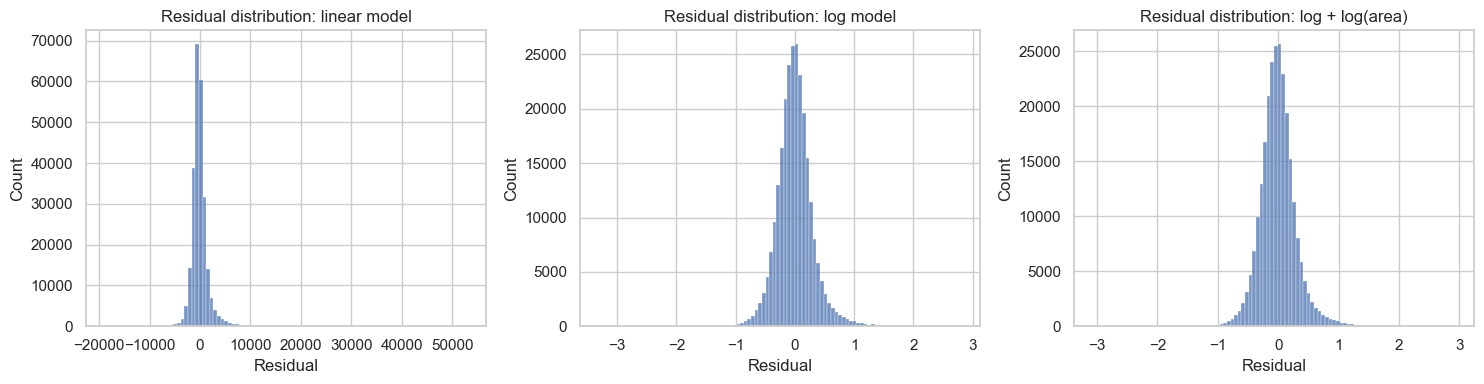

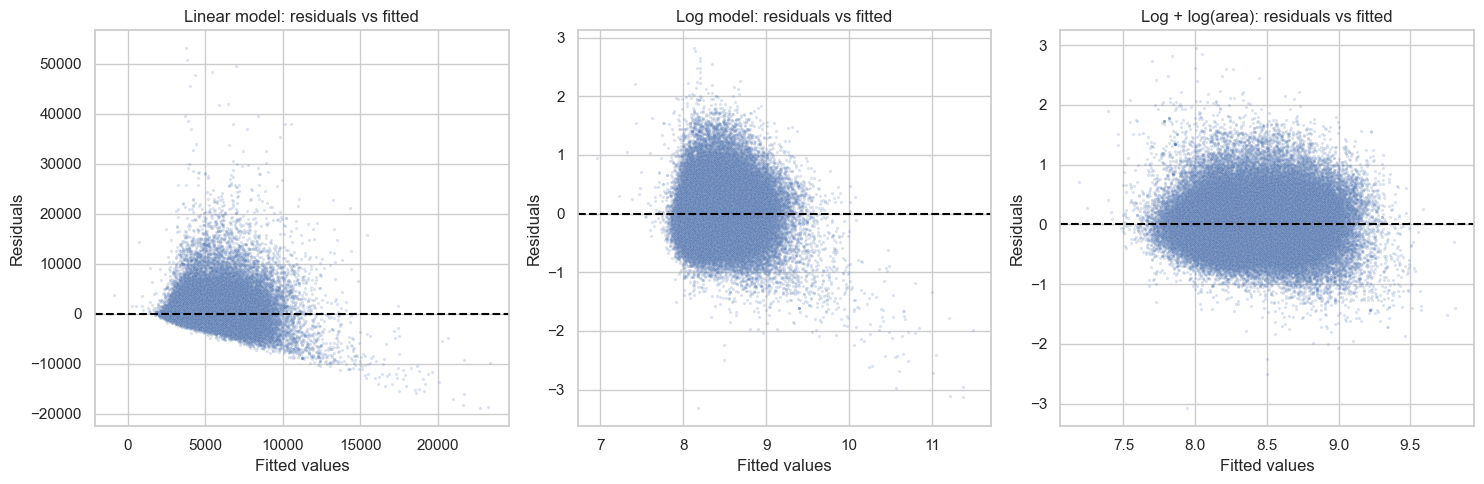

In [112]:
# 6.4 Compare model specifications

comparison_models = pd.DataFrame({
    "Model": ["Linear", "Log", "Log + log(area)"],
    "Observations": [
        int(model_linear.nobs),
        int(model_log.nobs),
        int(model_log_area.nobs)
    ],
    "Adj_R2": [
        model_linear.rsquared_adj,
        model_log.rsquared_adj,
        model_log_area.rsquared_adj
    ],
    "AIC": [
        model_linear.aic,
        model_log.aic,
        model_log_area.aic
    ],
    "BIC": [
        model_linear.bic,
        model_log.bic,
        model_log_area.bic
    ]
})

display(comparison_models)

# residual histograms
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(model_linear.resid, bins=100, ax=axes[0])
axes[0].set_title("Residual distribution: linear model")
axes[0].set_xlabel("Residual")

sns.histplot(model_log.resid, bins=100, ax=axes[1])
axes[1].set_title("Residual distribution: log model")
axes[1].set_xlabel("Residual")

sns.histplot(model_log_area.resid, bins=100, ax=axes[2])
axes[2].set_title("Residual distribution: log + log(area)")
axes[2].set_xlabel("Residual")

plt.tight_layout()
plt.show()

# residuals versus fitted
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.scatterplot(
    x=model_linear.fittedvalues,
    y=model_linear.resid,
    s=5,
    alpha=0.2,
    ax=axes[0]
)
axes[0].axhline(0, color="black", linestyle="--")
axes[0].set_title("Linear model: residuals vs fitted")
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")

sns.scatterplot(
    x=model_log.fittedvalues,
    y=model_log.resid,
    s=5,
    alpha=0.2,
    ax=axes[1]
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Log model: residuals vs fitted")
axes[1].set_xlabel("Fitted values")
axes[1].set_ylabel("Residuals")

sns.scatterplot(
    x=model_log_area.fittedvalues,
    y=model_log_area.resid,
    s=5,
    alpha=0.2,
    ax=axes[2]
)
axes[2].axhline(0, color="black", linestyle="--")
axes[2].set_title("Log + log(area): residuals vs fitted")
axes[2].set_xlabel("Fitted values")
axes[2].set_ylabel("Residuals")

plt.tight_layout()
plt.show()

### Interpretation of model comparison

The comparison above is used to select the preferred regression specification.

If the log-based specifications exhibit improved residual symmetry and reduced heteroskedasticity relative to the linear model, this indicates that modelling electricity demand on a logarithmic scale provides a more appropriate empirical representation of postcode-level variation.

If the log-log model further improves residual behaviour or fit relative to the simpler log-level model, this suggests that the relationship between floor area and electricity demand is better captured as a proportional rather than linear effect.

On this basis, the preferred specification is selected for the subsequent inference and prediction analysis. The next section focuses only on the preferred model, so that additional diagnostics are applied in a disciplined and non-redundant way.

### 6.5 Inference robustness of the preferred regression model

Once a preferred regression specification has been selected, the next question is whether the statistical inference associated with that model is reliable.

A key assumption of conventional Ordinary Least Squares inference is homoskedasticity, meaning that the variance of the regression residuals is constant across observations:

$$
Var(\varepsilon_{pc6} \mid X_{pc6}) = \sigma^2
$$

If this assumption is violated, the OLS coefficient estimates remain unbiased, but the conventional standard errors may no longer be reliable. In that case, t-statistics, p-values, and confidence intervals based on the usual covariance matrix may be misleading.

To assess this issue, a Breusch-Pagan test is applied to the preferred regression specification. The null hypothesis is:

$$
H_0: Var(\varepsilon_{pc6} \mid X_{pc6}) = \sigma^2
$$

The alternative hypothesis is that the variance of the residuals depends on the explanatory variables.

Regardless of whether the formal test rejects homoskedasticity, it is common in cross-sectional data to report heteroskedasticity-robust standard errors as a conservative inferential correction. For that reason, the preferred regression model is also re-estimated using HC3 robust standard errors.

This adjustment does not change the estimated coefficients. Instead, it adjusts the estimated standard errors, confidence intervals, and p-values so that inference remains valid under heteroskedasticity.

In the analysis below, the preferred model is the log-log specification with logarithmic floor area. If a different model is preferred based on the comparison above, the same procedure should be applied to that alternative model instead.

In [113]:
# 6.5 Heteroskedasticity diagnostic and robust standard errors
# preferred model: model_log_area

from statsmodels.stats.diagnostic import het_breuschpagan

# Breusch-Pagan test
residuals_pref = model_log_area.resid
exog_pref = model_log_area.model.exog

bp_test = het_breuschpagan(residuals_pref, exog_pref)

bp_results = pd.DataFrame({
    "Statistic": [
        "Lagrange multiplier statistic",
        "p-value",
        "f-value",
        "f p-value"
    ],
    "Value": bp_test
})

display(bp_results)

# re-estimate preferred model with HC3 robust standard errors
model_log_area_robust = sm.OLS(y_log_area, X_log_area).fit(cov_type="HC3")

print(model_log_area_robust.summary())

coef_comparison = pd.DataFrame({
    "coef_OLS": model_log_area.params,
    "se_OLS": model_log_area.bse,
    "pval_OLS": model_log_area.pvalues,
    "coef_HC3": model_log_area_robust.params,
    "se_HC3": model_log_area_robust.bse,
    "pval_HC3": model_log_area_robust.pvalues
})

display(coef_comparison)

,Statistic,Value
0,Lagrange multiplier statistic,16426.435992
1,p-value,0.000000
2,f-value,762.751891
3,f p-value,0.000000


                            OLS Regression Results                            
Dep. Variable:       log_kwh_norm_pc6   R-squared:                       0.388
Model:                            OLS   Adj. R-squared:                  0.388
Method:                 Least Squares   F-statistic:                     5101.
Date:                Tue, 17 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:49:04   Log-Likelihood:                -56718.
No. Observations:              257669   AIC:                         1.135e+05
Df Residuals:                  257645   BIC:                         1.137e+05
Df Model:                          23                                         
Covariance Type:                  HC3                                         
                                                            coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------

,coef_OLS,se_OLS,pval_OLS,coef_HC3,se_HC3,pval_HC3
const,3.522148,0.052645,0.000000e+00,3.522148,0.075448,0.000000e+00
log_mean_oppervlakte,0.537571,0.002544,0.000000e+00,0.537571,0.003676,0.000000e+00
mean_bouwjaar,0.001270,0.000027,0.000000e+00,0.001270,0.000039,3.225450e-238
share_has_gas,-0.221134,0.002395,0.000000e+00,-0.221134,0.003123,0.000000e+00
share_woning_type_Appartement,0.109814,0.005090,3.923736e-103,0.109814,0.007670,1.726556e-46
share_woning_type_Flatwoning (overig),0.098909,0.004750,3.080478e-96,0.098909,0.007276,4.324950e-42
share_woning_type_Galerijwoning,0.146010,0.011402,1.575232e-37,0.146010,0.015015,2.376264e-22
share_woning_type_Maisonnette,0.091421,0.007414,6.259215e-35,0.091421,0.009526,8.208834e-22
share_woning_type_Portiekwoning,0.056755,0.017438,1.134967e-03,0.056755,0.019298,3.270753e-03
share_woning_type_Rijwoning hoek,0.042245,0.007052,2.096404e-09,0.042245,0.008862,1.867368e-06


### Interpretation of inference robustness

The comparison between conventional and HC3-robust standard errors indicates whether heteroskedasticity materially affects statistical inference in the preferred model.

If the robust standard errors are similar to the conventional ones, the substantive interpretation of the model is not sensitive to mild heteroskedasticity. If some standard errors increase meaningfully under HC3 correction, then the coefficient estimates themselves remain unchanged, but the strength of statistical evidence associated with certain predictors becomes weaker.

Because the chapter is primarily concerned with structural interpretation rather than hypothesis testing alone, emphasis is placed on the direction, relative magnitude, and robustness of the estimated associations rather than on p-values in isolation.

### 6.6 Out-of-sample predictive assessment of the preferred regression model

The previous sections evaluated model adequacy primarily using in-sample criteria such as Adjusted $R^2$, AIC, BIC, and residual diagnostics. These metrics are useful for comparing candidate specifications, but they do not directly indicate how well the preferred model generalizes to unseen data.

To assess out-of-sample predictive performance, the preferred regression specification is evaluated using 10-fold cross-validation. In this procedure, the dataset is partitioned into ten approximately equal folds. For each iteration, the model is trained on nine folds and evaluated on the remaining fold. This process is repeated until each fold has served once as the validation sample.

The evaluation metric is the mean squared error:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

where:

- $y_i$ is the observed value  
- $\hat{y}_i$ is the predicted value  
- $n$ is the number of validation observations

Because the preferred regression model is estimated in log space, the resulting cross-validation error is also measured in log space.

To provide a reference point for interpretation, the regression model is compared with a naive baseline predictor that always predicts the sample mean of the dependent variable. A meaningful reduction in prediction error relative to this baseline indicates that the model captures systematic structure in the postcode-level data rather than only reproducing the average outcome.

In [114]:
# 6.6 Cross-validation of the preferred regression model

from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.dummy import DummyRegressor

# predictors and dependent variable for preferred model
X_cv = reg_data_log[
    ["log_mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
].copy()

y_cv = reg_data_log["log_kwh_norm_pc6"].copy()

# naive baseline
dummy = DummyRegressor(strategy="mean")

dummy_scores = cross_val_score(
    dummy,
    X_cv,
    y_cv,
    cv=10,
    scoring="neg_mean_squared_error"
)

# preferred regression model
model_cv = LinearRegression()

scores_cv = cross_val_score(
    model_cv,
    X_cv,
    y_cv,
    cv=10,
    scoring="neg_mean_squared_error"
)

cv_results = pd.DataFrame({
    "Model": ["Dummy mean baseline", "Preferred regression model"],
    "Mean_CV_MSE": [-dummy_scores.mean(), -scores_cv.mean()],
    "Std_CV_MSE": [dummy_scores.std(), scores_cv.std()]
})

display(cv_results)

,Model,Mean_CV_MSE,Std_CV_MSE
0,Dummy mean baseline,0.149117,0.014171
1,Preferred regression model,0.092282,0.011145


### Interpretation of cross-validation results

The cross-validation results indicate how well the preferred regression specification generalizes to unseen postcode observations.

If the regression model achieves a substantially lower mean cross-validation error than the naive mean-prediction baseline, this indicates that the model captures meaningful structural information in the housing variables.

The standard deviation of the cross-validation error across folds provides an indication of stability. A relatively small standard deviation suggests that predictive performance is not driven by a small subset of postcode areas but is reasonably consistent across the sample.

This predictive evaluation remains secondary to the main explanatory purpose of the chapter, but it is necessary for assessing whether the preferred regression model has practical predictive value beyond in-sample fit.

### 6.7 Nonlinear benchmark: Random Forest

The preferred regression model remains restricted to an additive functional form. Even when logarithmic transformations are introduced, the model still imposes a relatively structured relationship between the explanatory variables and electricity demand.

To assess whether more flexible nonlinear relationships provide improved predictive performance, a Random Forest regression model is estimated as a benchmark.

Random Forest is an ensemble learning method that combines many decision trees. Each tree is estimated on a different bootstrap sample of the data, and predictions are averaged across trees. This method can capture:

- nonlinear relationships between predictors and the dependent variable  
- interactions between variables  
- threshold effects that do not need to be specified manually in advance

The purpose of this comparison is not to replace the regression framework, but to evaluate whether a more flexible nonlinear model extracts substantially more predictive information from the same predictor set.

To improve the credibility of the benchmark, a small grid search is first performed to select basic hyperparameters. This prevents the comparison from depending on arbitrary parameter choices and provides a fairer assessment of the predictive potential of the Random Forest model.

The Random Forest model is then evaluated using the same 10-fold cross-validation procedure as the preferred regression specification, so that predictive performance can be compared on a consistent basis.

In [115]:
# 6.7 Random Forest benchmark with basic tuning

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# predictors and target
X_rf = reg_data_log[
    ["log_mean_oppervlakte", "mean_bouwjaar", "share_has_gas"]
    + woningtype_cols
    + label_cols
].copy()

y_rf = reg_data_log["log_kwh_norm_pc6"].copy()

# small hyperparameter grid
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

rf = RandomForestRegressor(random_state=0)

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_rf, y_rf)

rf_model = grid.best_estimator_

print("Best RF parameters:", grid.best_params_)

scores_rf = cross_val_score(
    rf_model,
    X_rf,
    y_rf,
    cv=10,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

rf_results = pd.DataFrame({
    "Model": ["Preferred regression model", "Random Forest"],
    "Mean_CV_MSE": [-scores_cv.mean(), -scores_rf.mean()],
    "Std_CV_MSE": [scores_cv.std(), scores_rf.std()]
})

display(rf_results)

Best RF parameters: {'max_depth': 10, 'n_estimators': 200}


,Model,Mean_CV_MSE,Std_CV_MSE
0,Preferred regression model,0.092282,0.011145
1,Random Forest,0.085688,0.010513


### Interpretation of nonlinear benchmark results

The Random Forest results are compared directly with the cross-validation performance of the preferred regression model.

If the Random Forest achieves a meaningfully lower cross-validation error, this indicates that nonlinearities or interactions among housing characteristics contain predictive information that is not fully captured by the regression framework.

If the improvement is modest, this suggests that the regression model already captures the main structural regularities in the data, while the nonlinear benchmark extracts only a limited additional signal.

This comparison is useful because it clarifies the trade-off between two modelling objectives:

- **interpretability**, which is stronger in the regression framework  
- **predictive flexibility**, which is stronger in the Random Forest framework

For the purposes of this thesis, the regression model remains central because it allows direct interpretation of how structural housing composition relates to electricity demand. The Random Forest model is included only as a predictive benchmark.

### 6.8 Concluding remarks for Chapter 6

This chapter estimated and compared alternative postcode-level regression models of normalized electricity demand using structural housing characteristics.

The analysis first developed a set of interpretable regression specifications and selected a preferred model on the basis of model fit and residual behaviour. It then assessed whether inference for the preferred specification is robust to heteroskedasticity and evaluated its out-of-sample predictive performance using cross-validation.

Finally, the preferred regression model was compared with a nonlinear Random Forest benchmark to assess whether substantial predictive gains can be obtained from a more flexible modelling approach.

Taken together, these results clarify both the explanatory and predictive value of postcode-level structural housing variables. The regression framework provides interpretable evidence on how housing composition is associated with normalized electricity demand, while the benchmark comparison indicates whether important nonlinear predictive structure remains beyond the preferred specification.

Additional exploratory feature-selection analysis using LASSO is not included in the main chapter because it does not materially alter the interpretation strategy of the thesis. If desired, this can be reported separately in an appendix as a robustness exercise.

# Questions
How do I model energy label? 
1. Efficiency order 1->12 (ordinal) or in another way?
Ans: Approach it like a categorical variable.
2. Calculate the distribution of the variance of dwelling features within a PC6 (mainly for surface area and then for the rest)
3. Check wayback machine to realize what the source of our data is.